# **Prédiction des charges médicales**

## **1. Introduction et Description du Dataset**

### **Introduction du projet**

Dans le cadre du module de **Machine Learning**, ce projet se concentre sur l’étude d’un problème de **régression** appliqué au domaine de la santé. L’objectif principal est d’analyser et de modéliser les **coûts médicaux individuels** aux États-Unis à partir d’un ensemble de données réel.

Ce travail suit une démarche complète de **Data Science**, comprenant plusieurs étapes essentielles :  
- l’exploration et la compréhension des données,  
- le prétraitement et la préparation des variables,  
- la construction de modèles de régression,  
- ainsi que l’évaluation des performances des modèles obtenus.  

L’enjeu est d’identifier les facteurs influençant les charges médicales et de proposer un modèle capable de prédire ces coûts de manière fiable.

### **Description du dataset**

Le jeu de données utilisé regroupe des informations sur des bénéficiaires d’assurance santé aux États-Unis, ainsi que les charges médicales associées. Il contient des variables à la fois numériques et catégorielles décrivant les caractéristiques individuelles et leur impact sur les coûts.

### **Variables du dataset**

| Variable   | Type         | Description                                      | Valeurs / Intervalle |
|-----------|-------------|--------------------------------------------------|----------------------|
| **age**    | Numérique    | Âge du bénéficiaire principal                    | 18 – 64 ans          |
| **sex**    | Catégorielle | Sexe du bénéficiaire                             | female, male         |
| **bmi**    | Numérique    | Indice de masse corporelle (IMC)                 | 15.96 – 53.13        |
| **children** | Numérique | Nombre d’enfants ou de personnes à charge        | 0 – 5                |
| **smoker** | Catégorielle | Indique si la personne est fumeuse ou non        | yes, no              |
| **region** | Catégorielle | Région de résidence aux États-Unis               | southwest, southeast, northwest, northeast |
| **charges** | Numérique  | Coûts médicaux facturés (variable cible)         | 1 121 – 63 770 $     |


### **Variable cible**

La variable **charges** représente le montant des frais médicaux facturés aux assurés. Elle constitue la **variable à prédire** dans ce projet de régression.



## **2. Importation des librairies**

In [1]:
# Manipulation des données
import pandas as pd          # DataFrames, lecture CSV, manipulation tabulaire
import numpy as np           # Calculs numériques, tableaux, opérations vectorielles
from collections import Counter  # Comptage d'occurrences pour le vote des features
from matplotlib.patches import Patch  # Pour la légende personnalisée

# Visualisation
import matplotlib.pyplot as plt   # Graphiques de base : histogrammes, scatter, barres
import seaborn as sns             # Visualisations statistiques : heatmap, pairplot, violin

# Prétraitement 
from sklearn.preprocessing import StandardScaler

# Séparation et validation
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV
# train_test_split divise en jeux d'entraînement et de test
# cross_val_score: évalue la robustesse par validation croisée k-fold
# KFold: stratégie de découpage des folds
# GridSearchCV: recherche exhaustive des meilleurs hyperparamètres

# Modèles de régression
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, lasso_path

# Métriques d'évaluation
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Sélection de features
from sklearn.feature_selection import RFE
# RFE : Recursive Feature Elimination — supprime itérativement les features inutiles

# Modèles statistiques (p-values, backward elimination) 
import statsmodels.api as sm

# Réglages d'affichage 
import warnings
warnings.filterwarnings('ignore')                          # Masque les avertissements non critiques
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)                  # Taille par défaut des figures
pd.set_option('display.float_format', '{:.4f}'.format)    # Affiche 4 décimales dans les DataFrames

print('Toutes les librairies importées avec succès')

Toutes les librairies importées avec succès


## **3. Chargement des données**

## Exploration initiale du dataset

Cette section permet d’effectuer une première analyse exploratoire des données.  
Elle consiste à :
- visualiser les premières et dernières lignes du dataset pour avoir un aperçu global
- identifier les dimensions du jeu de données
- examiner la structure des données (types, valeurs manquantes)
- générer des statistiques descriptives pour les variables numériques
- analyser les types de variables et les différentes modalités des variables catégorielles

Cette étape est essentielle pour comprendre la nature des données avant de passer au prétraitement et à la modélisation.

In [2]:
# Chargement du fichier CSV dans un DataFrame pandas
df = pd.read_csv('medical-charges.csv')

# df.head() : 5 premières lignes
print('Premières lignes:')
display(df.head())

# df.tail() : 5 dernières lignes
print('\n Dernières lignes:')
display(df.tail())

# df.shape : dimensions du dataset (nb_lignes, nb_colonnes)
print(f'\n Dimensions : {df.shape[0]} observations × {df.shape[1]} variables')

# df.info() : types, mémoire, valeurs non-nulles par colonne
print('\n Informations générales:')
df.info()

# df.describe() : statistiques descriptives (count, mean, std, min, Q1, médiane, Q3, max) ─
print('\n Statistiques descriptives:')
display(df.describe())

# Vérification des types et modalités des variables catégorielles
print('\n Types de données :')
print(df.dtypes)
print('\n Modalités des variables catégorielles :')
for col in ['sex', 'smoker', 'region']:
    print(f'  {col} : {df[col].unique()}')  # Affiche les valeurs distinctes

Premières lignes:


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.9000,0,yes,southwest,16884.9240
1,18,male,33.7700,1,no,southeast,1725.5523
2,28,male,33.0000,3,no,southeast,4449.4620
3,33,male,22.7050,0,no,northwest,21984.4706
4,32,male,28.8800,0,no,northwest,3866.8552



 Dernières lignes:


,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.9700,3,no,northwest,10600.5483
1334,18,female,31.9200,0,no,northeast,2205.9808
1335,18,female,36.8500,0,no,southeast,1629.8335
1336,21,female,25.8000,0,no,southwest,2007.9450
1337,61,female,29.0700,0,yes,northwest,29141.3603



 Dimensions : 1338 observations × 7 variables

 Informations générales:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB

 Statistiques descriptives:


,age,bmi,children,charges
count,1338.0000,1338.0000,1338.0000,1338.0000
mean,39.2070,30.6634,1.0949,13270.4223
std,14.0500,6.0982,1.2055,12110.0112
min,18.0000,15.9600,0.0000,1121.8739
25%,27.0000,26.2963,0.0000,4740.2872
50%,39.0000,30.4000,1.0000,9382.0330
75%,51.0000,34.6938,2.0000,16639.9125
max,64.0000,53.1300,5.0000,63770.4280



 Types de données :
age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

 Modalités des variables catégorielles :
  sex : ['female' 'male']
  smoker : ['yes' 'no']
  region : ['southwest' 'southeast' 'northwest' 'northeast']


**Interprétation — Exploration initiale du dataset**

Le dataset contient **1 338 observations et 7 variables** (6 features + 1 variable cible `charges`).
- **Aucune valeur manquante** n'est détectée à ce stade — le dataset est relativement propre.
- Les types sont cohérents : les variables numériques (`age`, `bmi`, `children`, `charges`) sont bien en `float64`/`int64`, et les variables catégorielles (`sex`, `smoker`, `region`) sont en `object`.
- Les statistiques descriptives révèlent que `charges` présente une **forte dispersion** (std ≈ 12 000 $, max ≈ 63 770 $) par rapport à sa moyenne (≈ 13 270 $), suggérant une distribution asymétrique avec des valeurs extrêmes.
- L'`age` varie de 18 à 64 ans et le `bmi` de 15.96 à 53.13, couvrant un large spectre de profils.
Cette première exploration confirme que le dataset est exploitable en l'état, mais que des transformations (encodage, standardisation) seront nécessaires avant la modélisation.


## **4. Analyse Exploratoire (EDA)**
L'EDA permet de comprendre en profondeur la structure du dataset avant toute transformation : distributions, relations entre variables, et détection d'anomalies.

### **4.1 Analyse Univariée**
Analyse de chaque variable indépendamment :
* Variables numériques → histogrammes (distribution) + boxplots (outliers)
* Variables catégorielles → countplots (fréquences des modalités)

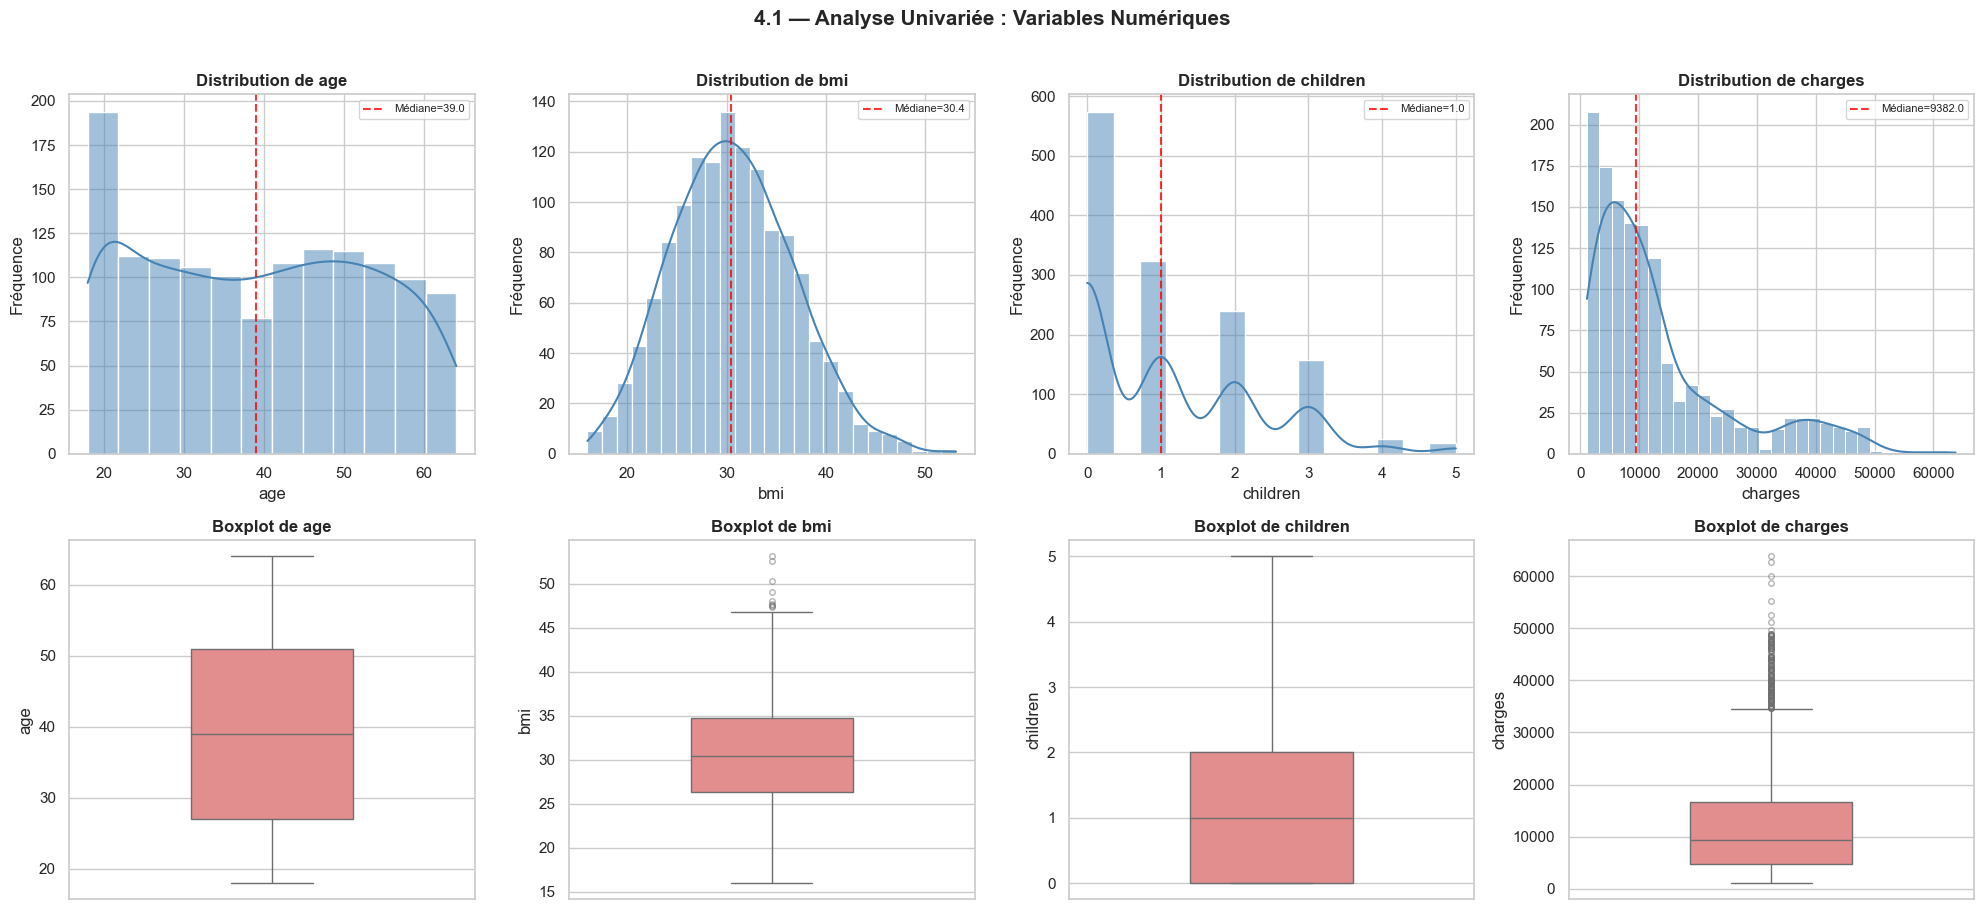

In [3]:
# Variables numériques
numerical_cols = ['age', 'bmi', 'children', 'charges']  # Liste des colonnes numériques

fig, axes = plt.subplots(2, 4, figsize=(20, 9))  # Grille 2 lignes × 4 colonnes
fig.suptitle('4.1 — Analyse Univariée : Variables Numériques', fontsize=15, fontweight='bold', y=1.01)

for i, col in enumerate(numerical_cols):

    # Ligne du haut : histogramme avec courbe de densité KDE
    # KDE (Kernel Density Estimate) = courbe de densité lissée superposée
    sns.histplot(df[col], kde=True, ax=axes[0, i], color='steelblue', edgecolor='white')
    median_val = df[col].median()  # Calcul de la médiane
    axes[0, i].axvline(median_val, color='red', linestyle='--', alpha=0.8, label=f'Médiane={median_val:.1f}')  # Ligne verticale à la médiane
    axes[0, i].set_title(f'Distribution de {col}', fontweight='bold')
    axes[0, i].set_xlabel(col)
    axes[0, i].set_ylabel('Fréquence')
    axes[0, i].legend(fontsize=8)

    # Ligne du bas : boxplot
    # Boxplot représente : Q1 (25%), médiane (50%), Q3 (75%) et les moustaches
    # Les points au-delà des moustaches = outliers potentiels
    sns.boxplot(y=df[col], ax=axes[1, i], color='lightcoral', width=0.4, flierprops={'marker': 'o', 'markersize': 4, 'alpha': 0.5})
    axes[1, i].set_title(f'Boxplot de {col}', fontweight='bold')
    axes[1, i].set_ylabel(col)

plt.tight_layout()
plt.savefig('4_1_univariate_numerical.png', dpi=150, bbox_inches='tight')
plt.show()

**Interprétation — Analyse Univariée : Variables Numériques**

- **`age`** : La distribution est quasi-uniforme entre 18 et 64 ans, avec un léger pic autour de 18-20 ans (jeunes adultes). Le boxplot ne révèle aucun outlier notable.
- **`bmi`** : Distribution en cloche bien centrée autour de 30 (seuil médical de l'obésité selon l'OMS). Quelques outliers au-delà de 45 sont détectables mais restent marginaux.
- **`children`** : Variable discrète avec une forte concentration en 0 (pas d'enfant). La majorité des assurés n'ont pas ou peu d'enfants à charge.
- **`charges`** : Distribution fortement **asymétrique à droite** — la médiane (~9 382 $) est bien inférieure à la moyenne (~13 270 $). Cela indique la présence de quelques individus avec des charges médicales très élevées.



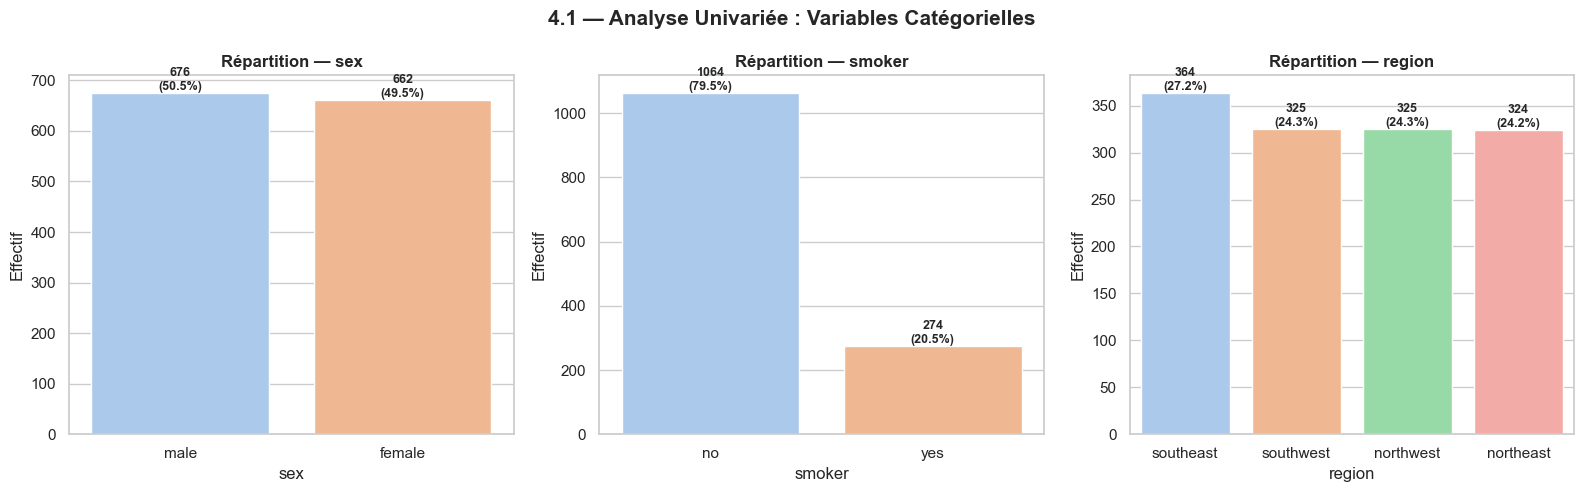

In [4]:
# Variables catégorielles
categorical_cols = ['sex', 'smoker', 'region'] 

fig, axes = plt.subplots(1, 3, figsize=(16, 5))  # 1 ligne × 3 graphiques
fig.suptitle('4.1 — Analyse Univariée : Variables Catégorielles', fontsize=15, fontweight='bold')

for i, col in enumerate(categorical_cols):
    order = df[col].value_counts().index  # Ordonne les barres par fréquence décroissante

    # countplot : compte et affiche l'effectif de chaque modalité
    sns.countplot(x=df[col], ax=axes[i], order=order, palette='pastel')
    axes[i].set_title(f'Répartition — {col}', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Effectif')

    # Affiche le comptage et le pourcentage au-dessus de chaque barre
    total = len(df)
    for p in axes[i].patches:
        count = int(p.get_height())             # Hauteur de barre = effectif
        pct   = 100 * count / total             # Conversion en pourcentage
        axes[i].annotate(f'{count}\n({pct:.1f}%)', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('4_1_univariate_categorical.png', dpi=150, bbox_inches='tight')
plt.show()

**Interprétation**

- **`sex`** : Répartition quasi-équilibrée — 676 femmes (50.5%) vs 662 hommes (49.5%). Le genre ne devrait donc pas introduire de biais lié au déséquilibre de classes.
- **`smoker`** : **79.5% de non-fumeurs** (1 064 individus) contre **20.5% de fumeurs** (274 individus). Ce déséquilibre notable est important : les fumeurs, bien que minoritaires, pourraient avoir un impact disproportionné sur les charges.
- **`region`** : Répartition relativement équilibrée entre les 4 régions américaines (Southeast légèrement surreprésenté avec 27.2%). Cela limite les biais géographiques dans la modélisation.



### **4.2 Analyse Bivariée**
Étude de la relation entre chaque feature et la variable cible charges.

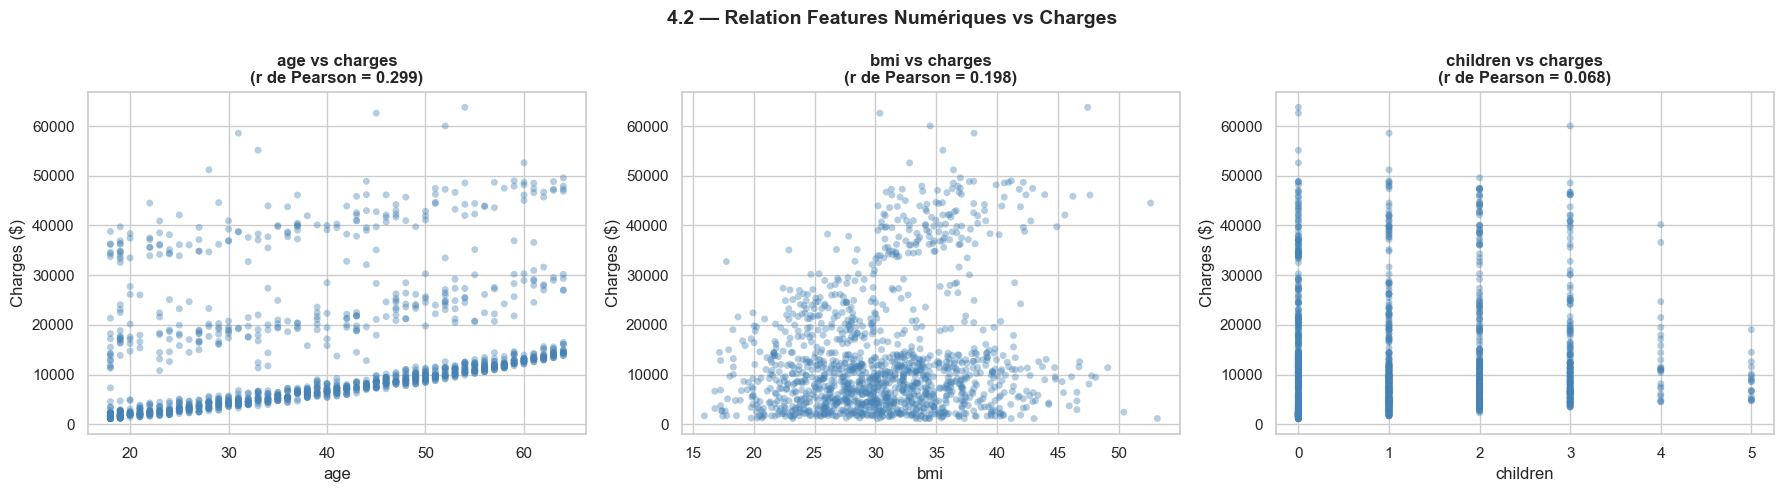

In [5]:
# Features numériques vs CHARGES : scatter plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('4.2 — Relation Features Numériques vs Charges', fontsize=14, fontweight='bold')

for i, col in enumerate(['age', 'bmi', 'children']):
    axes[i].scatter(df[col], df['charges'],
                    alpha=0.4,             # Semi-transparence pour mieux voir les zones denses
                    color='steelblue', edgecolors='none', s=25)
    corr = df[col].corr(df['charges'])     # Coefficient de corrélation de Pearson
    axes[i].set_title(f'{col} vs charges\n(r de Pearson = {corr:.3f})', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Charges ($)')

plt.tight_layout()
plt.savefig('4_2_num_vs_charges.png', dpi=150, bbox_inches='tight')
plt.show()

**Interprétation — Relation Features Numériques vs Charges**
- **`age` vs `charges`** (r ≈ 0.299) : Corrélation positive modérée. On observe visuellement **3 bandes horizontales** dans le scatter plot, correspondant aux 3 sous-groupes (non-fumeurs, fumeurs à BMI normal, fumeurs obèses). L'âge seul explique peu la variance des charges.
- **`bmi` vs `charges`** (r ≈ 0.198) : Corrélation faible. Le BMI n'a pas d'effet linéaire direct sur les charges, mais son interaction avec le statut fumeur est déterminante.
- **`children` vs `charges`** (r ≈ 0.068) : Corrélation très faible, quasi nulle. Le nombre d'enfants n'est pas un prédicteur significatif des coûts médicaux dans ce dataset.


**Analyse de l'impact du statut smoker sur les charges**

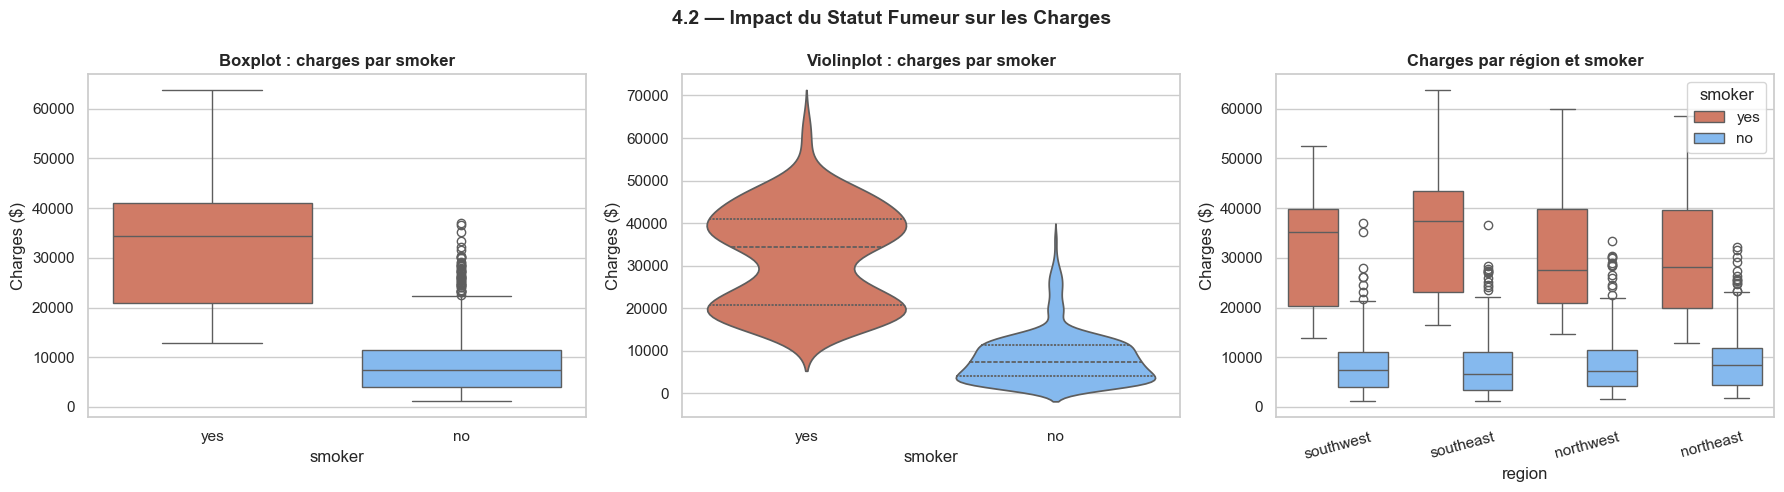

 Charges par statut fumeur :
             mean     median        std        min        max
smoker                                                       
no      8434.2700  7345.4100  5993.7800  1121.8700 36910.6100
yes    32050.2300 34456.3500 11541.5500 12829.4600 63770.4300


In [6]:
# Impact du statut FUMEUR sur les charges
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('4.2 — Impact du Statut Fumeur sur les Charges', fontsize=14, fontweight='bold')

# Boxplot : Q1, médiane, Q3, moustaches et outliers par groupe
sns.boxplot(x='smoker', y='charges', data=df, ax=axes[0], palette={'yes': '#e17055', 'no': '#74b9ff'}, order=['yes', 'no'])
axes[0].set_title('Boxplot : charges par smoker', fontweight='bold')
axes[0].set_ylabel('Charges ($)')

# Violinplot : montre la densité de la distribution en plus du boxplot
# inner='quartile' affiche les quartiles à l'intérieur du violon
sns.violinplot(x='smoker', y='charges', data=df, ax=axes[1],
               palette={'yes': '#e17055', 'no': '#74b9ff'},
               order=['yes', 'no'], inner='quartile')
axes[1].set_title('Violinplot : charges par smoker', fontweight='bold')
axes[1].set_ylabel('Charges ($)')

# Boxplot charges par région, coloré par smoker — interaction région × smoker
sns.boxplot(x='region', y='charges', hue='smoker', data=df, ax=axes[2],
            palette={'yes': '#e17055', 'no': '#74b9ff'})
axes[2].set_title('Charges par région et smoker', fontweight='bold')
axes[2].set_ylabel('Charges ($)')
axes[2].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('4_2_smoker_impact.png', dpi=150, bbox_inches='tight')
plt.show()

# Statistiques descriptives par groupe smoker
print(' Charges par statut fumeur :')
print(df.groupby('smoker')['charges'].agg(['mean', 'median', 'std', 'min', 'max']).round(2))

**Interprétation — Impact du Statut Fumeur sur les Charges**
Le statut fumeur est de loin le **facteur le plus discriminant** du dataset :
- **Moyenne charges fumeurs ≈ 32 050**  vs  **non-fumeurs ≈ 8 434** → les fumeurs paient **environ 3.8× plus** en charges médicales.
- Le boxplot montre que même le **1er quartile (Q1) des fumeurs** dépasse la **médiane des non-fumeurs** — les deux distributions ne se chevauchent pratiquement pas.
- Le violin plot confirme deux distributions très distinctes : les non-fumeurs ont une distribution concentrée et basse, les fumeurs une distribution étalée et haute.
- **Par région :** L'effet fumeur est **homogène** quelle que soit la région géographique — le surcoût lié au tabagisme n'est pas amplifié par la région.



**Analyse de l'interaction bmi × smoker sur les charges**

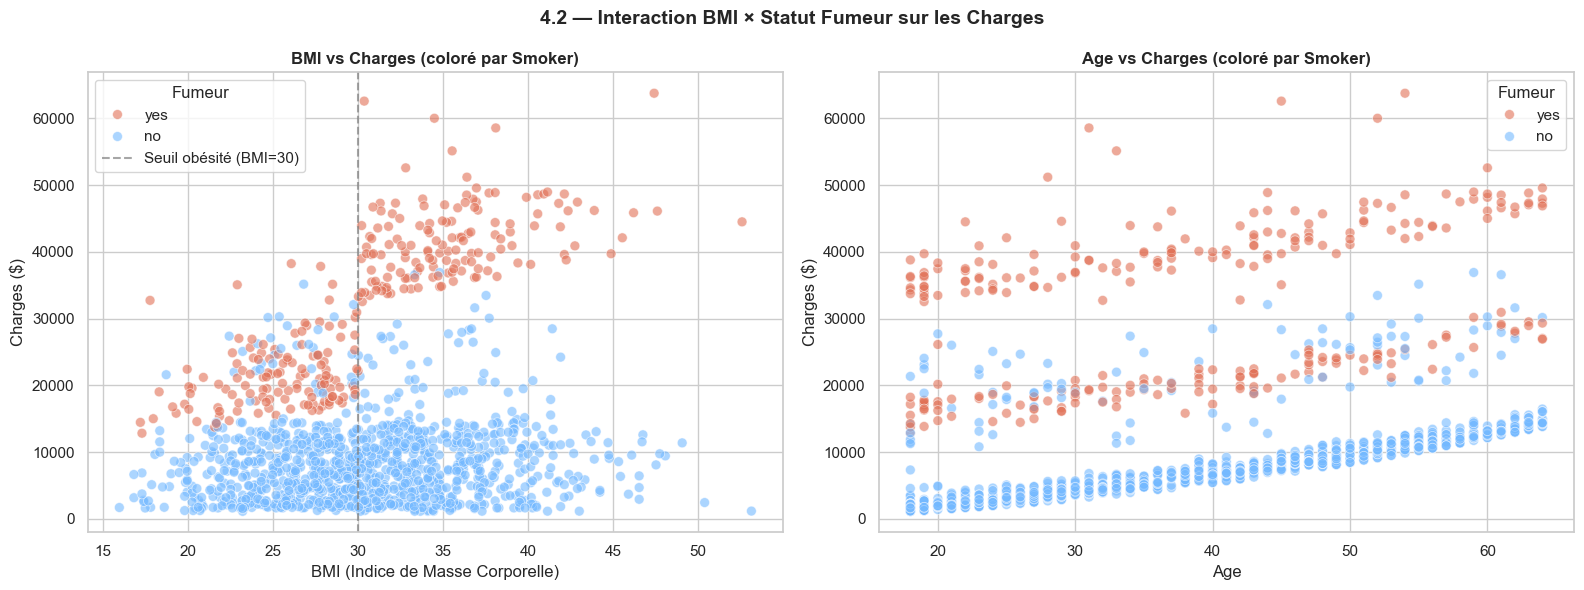

In [7]:
# Interaction BMI × SMOKER sur les charges
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('4.2 — Interaction BMI × Statut Fumeur sur les Charges', fontsize=14, fontweight='bold')

# Scatter BMI vs Charges coloré par smoker : révèle l'effet amplificateur du tabagisme
sns.scatterplot(x='bmi', y='charges', hue='smoker', data=df, ax=axes[0], palette={'yes': '#e17055', 'no': '#74b9ff'}, alpha=0.6, s=50)
# Ligne de référence médicale : BMI = 30 = seuil de l'obésité
axes[0].axvline(x=30, color='gray', linestyle='--', alpha=0.7, label='Seuil obésité (BMI=30)')
axes[0].set_title('BMI vs Charges (coloré par Smoker)', fontweight='bold')
axes[0].set_xlabel('BMI (Indice de Masse Corporelle)')
axes[0].set_ylabel('Charges ($)')
axes[0].legend(title='Fumeur')

# Scatter AGE vs Charges coloré par smoker
sns.scatterplot(x='age', y='charges', hue='smoker', data=df, ax=axes[1], palette={'yes': '#e17055', 'no': '#74b9ff'}, alpha=0.6, s=50)
axes[1].set_title('Age vs Charges (coloré par Smoker)', fontweight='bold')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Charges ($)')
axes[1].legend(title='Fumeur')

plt.tight_layout()
plt.savefig('4_2_bmi_age_smoker.png', dpi=150, bbox_inches='tight')
plt.show()

**Interprétation — Interaction BMI × Statut Fumeur**

Ce graphique est l'une des visualisations les plus révélatrices du notebook :
- **Non-fumeurs** (bleu) : les charges restent basses et relativement stables quel que soit le BMI — la relation BMI-charges est quasiment inexistante pour eux.
- **Fumeurs** (rouge) : deux sous-groupes apparaissent clairement :
  - **Fumeurs avec BMI < 30** : charges élevées (~20 000–35 000 $)
  - **Fumeurs avec BMI > 30** (obèses) : charges **très élevées** (~30 000–63 000 $)

Le **seuil d'obésité BMI = 30** agit comme un point de rupture chez les fumeurs, révélant un **effet synergique** (tabac + obésité = charges exponentiellement plus élevées).

Dans le scatter Age vs Charges, on distingue également **3 droites parallèles ascendantes** selon l'âge : non-fumeurs en bas, fumeurs au milieu, fumeurs obèses en haut.


### **4.3 Analyse Multivariée**
Étude des interactions entre plusieurs variables simultanément : matrice de corrélation et pairplot.

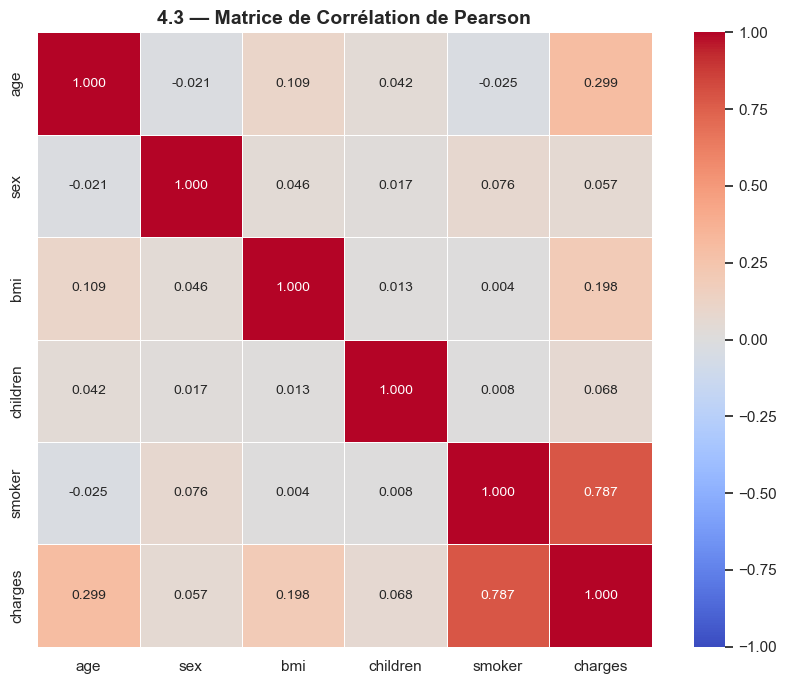


 Corrélations avec 'charges' (triées par valeur absolue) :
smoker     0.7873
age        0.2990
bmi        0.1983
children   0.0680
sex        0.0573
Name: charges, dtype: float64


In [8]:
# Matrice de corrélation (HEATMAP)
# Encodage temporaire de smoker et sex pour les inclure dans la corrélation
df_corr = df.copy()
df_corr['smoker_bin'] = (df_corr['smoker'] == 'yes').astype(int)  # yes=1, no=0
df_corr['sex_bin']    = (df_corr['sex'] == 'male').astype(int)    # male=1, female=0

# Sélection des variables pour la matrice
corr_vars = ['age', 'sex_bin', 'bmi', 'children', 'smoker_bin', 'charges']
corr_matrix = df_corr[corr_vars].corr()  # Coefficient de Pearson entre toutes les paires

# Renommage pour l'affichage
corr_matrix.columns = ['age', 'sex', 'bmi', 'children', 'smoker', 'charges']
corr_matrix.index   = ['age', 'sex', 'bmi', 'children', 'smoker', 'charges']

plt.figure(figsize=(9, 7))
sns.heatmap(
    corr_matrix,
    annot=True,        # Affiche les valeurs dans les cellules
    fmt='.3f',         # Format 3 décimales
    cmap='coolwarm',   # Bleu=corrélation négative, Rouge=positive
    vmin=-1, vmax=1,   # Échelle fixe [-1, 1]
    square=True,       # Cellules carrées
    linewidths=0.5,    # Séparateur entre cellules
    annot_kws={'size': 10}
)
plt.title('4.3 — Matrice de Corrélation de Pearson', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('4_3_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Corrélations avec la variable cible triées
print("\n Corrélations avec 'charges' (triées par valeur absolue) :")
print(corr_matrix['charges'].drop('charges').abs().sort_values(ascending=False))

**Interprétation — Matrice de Corrélation**
La matrice de Pearson confirme et quantifie les observations visuelles :
>
> | Feature | Corrélation avec `charges` | Interprétation |
> |---|---|---|
> | `smoker` | **r ≈ 0.787** | Corrélation forte — prédicteur dominant |
> | `age` | r ≈ 0.299 | Corrélation modérée positive |
> | `bmi` | r ≈ 0.198 | Corrélation faible  |
> | `children` | r ≈ 0.068 | Quasi nulle |
> | `sex` | r ≈ 0.057 | Négligeable |
>
**Absence de multicolinéarité :** Les corrélations entre features sont toutes faibles (< 0.2), ce qui est excellent pour la régression linéaire — pas de redondance d'information entre variables explicatives. Cela garantit la stabilité des coefficients et facilite leur interprétation.


**Pairplot coloré par "Smoker"**

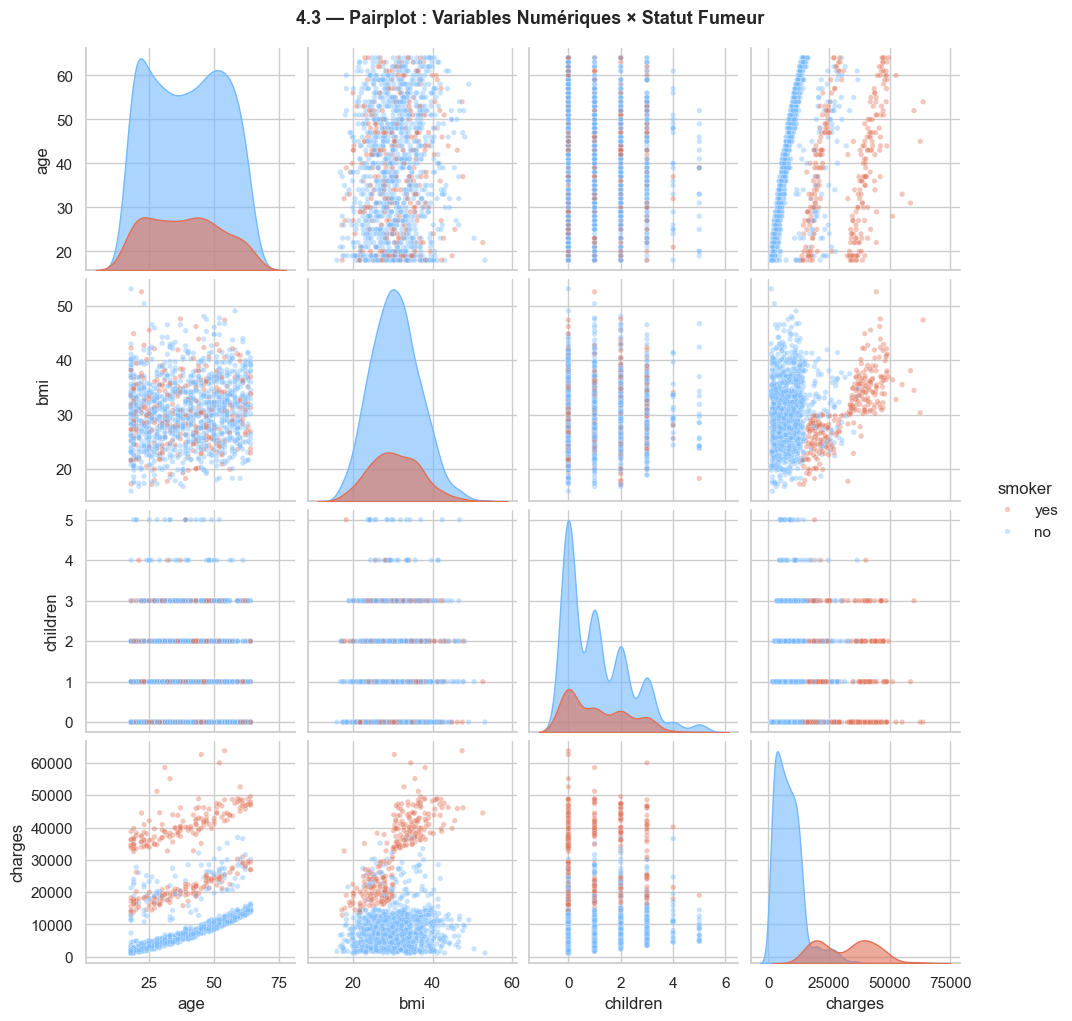

In [9]:
# Visualise toutes les relations paire-à-paire, colorées par smoker
pairplot_df = df[['age', 'bmi', 'children', 'charges', 'smoker']]

pp = sns.pairplot(
    pairplot_df,
    hue='smoker',                                      # Colorie par statut fumeur
    palette={'yes': '#e17055', 'no': '#74b9ff'},
    diag_kind='kde',                                   # Diagonale : courbe de densité
    plot_kws={'alpha': 0.4, 's': 15},                  # Points semi-transparents
    diag_kws={'alpha': 0.6}
)
pp.fig.suptitle('4.3 — Pairplot : Variables Numériques × Statut Fumeur',
                y=1.02, fontsize=13, fontweight='bold')
plt.savefig('4_3_pairplot_smoker.png', dpi=120, bbox_inches='tight')
plt.show()

**Interprétation — Pairplot (Relations paire-à-paire)**

Le pairplot coloré par `smoker` est très informatif :
 - **Diagonale (densités KDE)** : Les distributions des fumeurs (rouge) et non-fumeurs (bleu) sont bien séparées pour `charges`, confirmant leur impact. Pour `age` et `bmi`, les deux groupes se superposent — ces variables ne permettent pas de distinguer les fumeurs des non-fumeurs.
 - **`charges` vs `age`** : Trois bandes parallèles ascendantes sont clairement visibles, correspondant aux 3 clusters de risque.
 - **`charges` vs `bmi`** : Nuage bimodal chez les fumeurs (seuil BMI=30), nuage homogène chez les non-fumeurs.
 - **`age` vs `bmi`** : Distribution uniforme, sans structure — aucune corrélation entre âge et BMI.


### **4.4 Détection des Outliers**

**Méthode IQR (Interquartile Range) :** Un point est considéré outlier si :
- x < Q1 - 1.5 × IQR (borne inférieure)
- x > Q3 + 1.5 × IQR (borne supérieure)

Tableau récapitulatif des outliers (méthode IQR) :


,Q1,Q3,IQR,Borne inférieure,Borne supérieure,Nb outliers,% outliers
age,27.0000,51.0000,24.0000,-9.0000,87.0000,0.0000,0.0000
bmi,26.3000,34.6900,8.4000,13.7000,47.2900,9.0000,0.6700
children,0.0000,2.0000,2.0000,-3.0000,5.0000,0.0000,0.0000
charges,4740.2900,16639.9100,11899.6300,-13109.1500,34489.3500,139.0000,10.3900


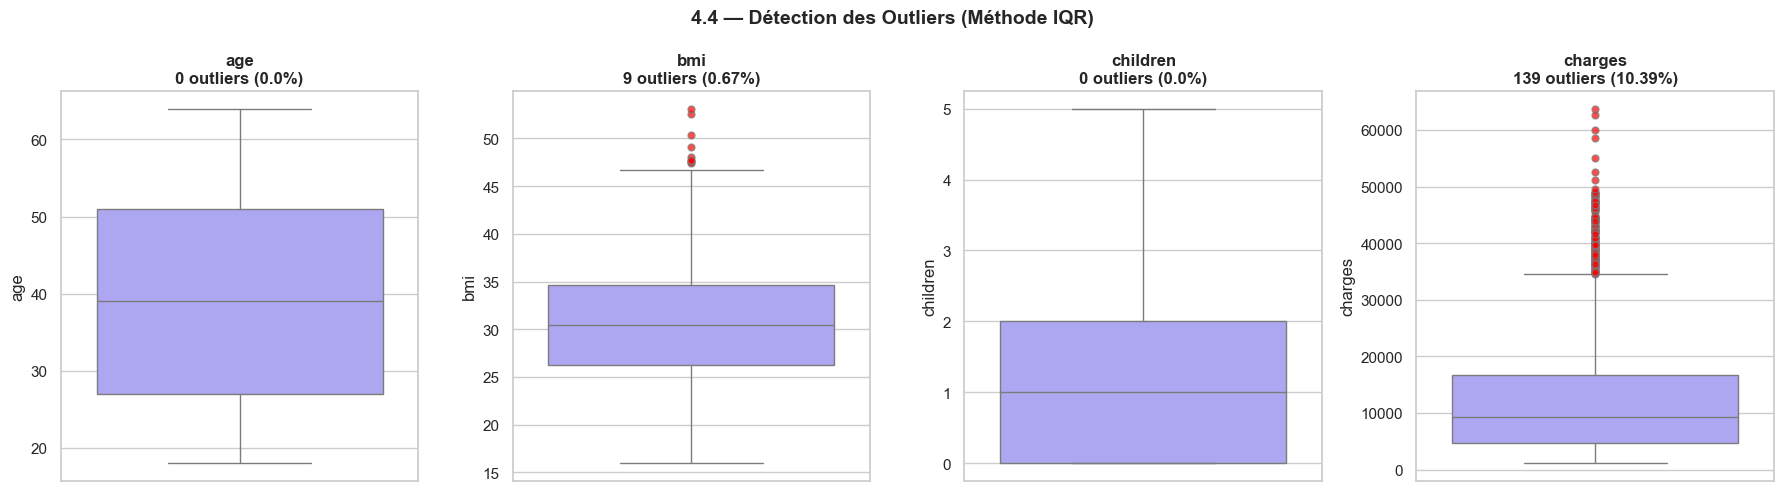

In [10]:
outlier_summary = {}  # Dictionnaire pour stocker les résultats

for col in numerical_cols:
    Q1  = df[col].quantile(0.25)   # 1er quartile (25e percentile)
    Q3  = df[col].quantile(0.75)   # 3e quartile (75e percentile)
    IQR = Q3 - Q1                  # Étendue interquartile
    lower = Q1 - 1.5 * IQR        # Borne inférieure : en dessous = outlier
    upper = Q3 + 1.5 * IQR        # Borne supérieure : au-dessus = outlier

    # Masque booléen des observations hors-bornes
    outlier_mask = (df[col] < lower) | (df[col] > upper)
    nb_out = outlier_mask.sum()  # Nombre d'outliers

    outlier_summary[col] = {
        'Q1': round(Q1, 2), 'Q3': round(Q3, 2), 'IQR': round(IQR, 2),
        'Borne inférieure': round(lower, 2), 'Borne supérieure': round(upper, 2),
        'Nb outliers': nb_out, '% outliers': round(nb_out / len(df) * 100, 2)
    }

print('Tableau récapitulatif des outliers (méthode IQR) :')
display(pd.DataFrame(outlier_summary).T)

# Visualisation via boxplots annotés
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('4.4 — Détection des Outliers (Méthode IQR)', fontsize=14, fontweight='bold')

for i, col in enumerate(numerical_cols):
    # flierprops : style des points outliers (marqués en rouge)
    sns.boxplot(y=df[col], ax=axes[i], color='#a29bfe',
                flierprops={'marker': 'o', 'markerfacecolor': 'red', 'markersize': 5, 'alpha': 0.7})
    nb_out = outlier_summary[col]['Nb outliers']
    pct    = outlier_summary[col]['% outliers']
    axes[i].set_title(f'{col}\n{nb_out} outliers ({pct}%)', fontweight='bold')
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.savefig('4_4_outliers_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()


**Interprétation — Détection des Outliers (Méthode IQR)**
>
> | Variable | Décision |
> |---|---|
> | `age` |  Aucun outlier — distribution uniforme propre |
> | `bmi` |  Quelques valeurs extrêmes (~0.7%) mais médicalement plausibles |
> | `children` |  Max=5 enfants — valeur réelle, non aberrante |
> | `charges` |  Nombreux outliers (~10%) selon la méthode IQR |
>
Pour **`charges`**, les ~139 valeurs au-dessus de la borne IQR supérieure ne sont **pas des erreurs** — elles correspondent aux fumeurs (et particulièrement aux fumeurs obèses) dont les coûts sont structurellement plus élevés. Les supprimer reviendrait à **biaiser le modèle** en sous-représentant ce groupe important.

=> **Décision :** Aucun outlier ne sera supprimé. Ces valeurs extrêmes sont **informatives et cohérentes** avec la réalité médicale. Les modèles régularisés (Ridge, Lasso) seront naturellement plus robustes à leur influence que la régression OLS classique.


## **5. Nettoyage et Prétraitement**
Transformation du dataset brut en format exploitable par les algorithmes de Machine Learning.

### **5.1 Valeurs Manquantes**


In [11]:
# isnull() : crée un masque booléen (True si NaN)
# .sum()   : compte les True par colonne = nombre de valeurs manquantes
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)

print(' Rapport des valeurs manquantes :')
display(pd.DataFrame({'Nb manquants': missing, 'Pourcentage (%)': missing_pct}))

print(f'\nTotal valeurs manquantes : {missing.sum()}')
if missing.sum() == 0:
    print(' Dataset complet. Aucun traitement des valeurs manquantes requis.')

 Rapport des valeurs manquantes :


,Nb manquants,Pourcentage (%)
age,0,0.0000
sex,0,0.0000
bmi,0,0.0000
children,0,0.0000
smoker,0,0.0000
region,0,0.0000
charges,0,0.0000



Total valeurs manquantes : 0
 Dataset complet. Aucun traitement des valeurs manquantes requis.


**Interprétation — Valeurs Manquantes**
Le dataset ne contient **aucune valeur manquante** (0 NaN sur l'ensemble des 7 variables × 1 338 observations). Cette complétude est rare pour des données réelles et simplifie considérablement le prétraitement — aucune imputation (moyenne, médiane, KNN, etc.) ne sera nécessaire.

### **5.2 Doublons**


In [12]:
# .duplicated() : retourne True pour les lignes identiques à une ligne précédente
nb_doublons = df.duplicated().sum()
print(f' Nombre de lignes dupliquées : {nb_doublons}')

if nb_doublons > 0:
    print('\nLignes dupliquées :')
    display(df[df.duplicated(keep=False)].sort_values(by=df.columns.tolist()))
    df = df.drop_duplicates().reset_index(drop=True)  # Garde la 1re occurrence
    print(f' Doublons supprimés. Nouvelles dimensions : {df.shape}')
else:
    print(' Aucun doublon — dataset propre.')

print(f'\nDimensions finales après nettoyage : {df.shape}')

 Nombre de lignes dupliquées : 1

Lignes dupliquées :


,age,sex,bmi,children,smoker,region,charges
195,19,male,30.5900,0,no,northwest,1639.5631
581,19,male,30.5900,0,no,northwest,1639.5631


 Doublons supprimés. Nouvelles dimensions : (1337, 7)

Dimensions finales après nettoyage : (1337, 7)


**Interprétation — Doublons**

**1 ligne dupliquée** a été détectée et supprimée. Le dataset passe de 1 338 à **1 337 observations**. Cette duplication était probablement due à une saisie double lors de la constitution du dataset.



### **5.3 Encodage des variables catégorielles**
**Stratégie choisie :**
- `sex`, `smoker` → **Encodage binaire** (2 modalités → 0/1), pas de risque de multicolinéarité
- `region` → **One-Hot Encoding** avec `drop_first=True` pour éviter la **dummy variable trap** (colinéarité parfaite entre les colonnes créées)

In [13]:
# Copie du DataFrame pour conserver les données originales intactes
df_encoded = df.copy()

# Encodage binaire de 'sex'
# male=1, female=0 → 2 modalités = 1 colonne suffit
df_encoded['sex'] = (df_encoded['sex'] == 'male').astype(int)
print("Encodage 'sex'    : male=1, female=0")

# Encodage binaire de 'smoker'
# yes=1, no=0 → variable binaire → encodage direct
df_encoded['smoker'] = (df_encoded['smoker'] == 'yes').astype(int)
print("Encodage 'smoker' : yes=1, no=0")

# One-Hot Encoding de 'region'
# 4 modalités → 3 colonnes binaires
# drop_first=True : supprime la 1re modalité alphabétique ('northeast') comme référence
# → évite la dummy variable trap (colinéarité parfaite entre les colonnes OHE)
df_encoded = pd.get_dummies(df_encoded, columns=['region'], drop_first=True, dtype=int)

print('\n Colonnes après encodage :')
print(df_encoded.columns.tolist())
print(f'\nDimensions : {df_encoded.shape}')
display(df_encoded.head(3))

Encodage 'sex'    : male=1, female=0
Encodage 'smoker' : yes=1, no=0

 Colonnes après encodage :
['age', 'sex', 'bmi', 'children', 'smoker', 'charges', 'region_northwest', 'region_southeast', 'region_southwest']

Dimensions : (1337, 9)


,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,0,27.9000,0,1,16884.9240,0,0,1
1,18,1,33.7700,1,0,1725.5523,0,1,0
2,28,1,33.0000,3,0,4449.4620,0,1,0


**Interprétation — Encodage des Variables Catégorielles**
Après encodage, le dataset passe de **7 à 9 colonnes** :
 - `sex` → 1 colonne binaire (`male=1, female=0`)
 - `smoker` → 1 colonne binaire (`yes=1, no=0`)
 - `region` → **3 colonnes OHE** (`region_northwest`, `region_southeast`, `region_southwest`) — la modalité `northeast` est la **référence implicite** (évite la dummy variable trap)

**Pourquoi `drop_first=True` pour `region` ?** Sans cette option, les 4 colonnes OHE seraient parfaitement colinéaires (leur somme = 1 pour chaque observation), ce qui rendrait la matrice X non-inversible et les coefficients OLS indéterminés.

**Pourquoi un encodage binaire direct pour `sex` et `smoker` ?** Ces variables n'ont que 2 modalités — un simple 0/1 suffit sans risque de multicolinéarité.



### **5.4 Feature Scaling**
**Pourquoi standardiser ?** Ridge, Lasso et ElasticNet pénalisent les valeurs absolues des coefficients. Sans standardisation, les features avec de grandes valeurs domineraient la pénalité.

**Formule :** `x_scaled = (x - μ) / σ` → moyenne = 0, écart-type = 1

### **5.5 Train/Test Split**
**⚠️ Règle anti-data leakage :** Le scaler est `fit` **uniquement** sur le train set. On applique ensuite `transform` sur train ET test avec les paramètres appris sur le train.

In [14]:
# ── Définition X (features) et y (cible) ─────────────────────────────────────
X = df_encoded.drop(columns=['charges'])   # Toutes les colonnes sauf la variable cible
y = df_encoded['charges']                  # Variable à prédire

print(f'Features X : {X.shape} → {X.columns.tolist()}')
print(f'Cible y    : {y.shape}')

# Split 80% train / 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 20% pour le test
    random_state=42      # Graine fixe
)
print(f'\nTrain : {X_train.shape[0]} obs | Test : {X_test.shape[0]} obs')

# Standardisation (après le split pour éviter le data leakage)
scaler = StandardScaler()  # Instanciation du scaler

# fit_transform sur le TRAIN : apprend μ et σ ET transforme en même temps
X_train_scaled = scaler.fit_transform(X_train)

# transform seulement sur le TEST : applique les μ et σ du train (jamais fit sur test)
X_test_scaled = scaler.transform(X_test)

# Reconversion en DataFrame pour conserver les noms des colonnes
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=X_test.columns,  index=X_test.index)

print('\n Standardisation appliquée (fit sur train uniquement)')
print('Vérification — moyenne sur train (doit être ≈ 0) :')
print(X_train_scaled.mean().round(6))

Features X : (1337, 8) → ['age', 'sex', 'bmi', 'children', 'smoker', 'region_northwest', 'region_southeast', 'region_southwest']
Cible y    : (1337,)

Train : 1069 obs | Test : 268 obs

 Standardisation appliquée (fit sur train uniquement)
Vérification — moyenne sur train (doit être ≈ 0) :
age                 0.0000
sex                 0.0000
bmi                 0.0000
children            0.0000
smoker              0.0000
region_northwest   -0.0000
region_southeast    0.0000
region_southwest    0.0000
dtype: float64


**Résultats du prétraitement**

Après la préparation des données, le dataset contient **1337 observations** et **8 variables explicatives**.  
La variable cible (**charges**) est correctement séparée des features.

La division des données a été effectuée comme suit :
- **Ensemble d’entraînement** : 1069 observations (80%)
- **Ensemble de test** : 268 observations (20%)

Concernant la standardisation :
- Elle a été appliquée uniquement sur l’ensemble d’entraînement (**fit**), puis utilisée sur le test (**transform**) afin d’éviter le *data leakage*.
- La vérification des moyennes des variables du train montre des valeurs proches de **0**, ce qui confirme que la standardisation a été correctement réalisée.

Ce prétraitement garantit des données prêtes pour l’entraînement des modèles de régression dans de bonnes conditions.

## **6. Modélisation**


| # | Modèle | Formule de minimisation |
|---|--------|------------------------|
| 1 | **Linear Regression** | Σ(y-ŷ)² |
| 2 | **Ridge (L2)** | Σ(y-ŷ)² + α·Σβj² |
| 3 | **Lasso (L1)** | Σ(y-ŷ)² + α·Σ\|βj\| |
| 4 | **ElasticNet (L1+L2)** | Σ(y-ŷ)² + α[l1·Σ\|βj\| + (1-l1)/2·Σβj²] |

### **6.1 Linear Regression**


Intercept (biais) : 13030.20

Coefficients (par valeur absolue décroissante) :
smoker             9234.3400
age                3472.9800
bmi                1927.8300
children            636.5000
region_southeast   -371.7800
region_southwest   -284.6100
region_northwest   -168.9400
sex                 -50.7500
dtype: float64


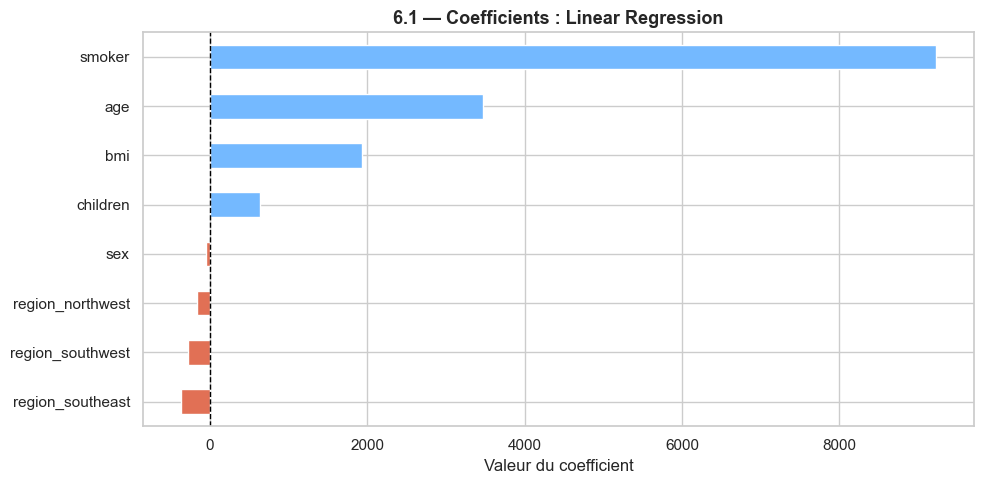


CV R² (5-fold) : 0.7228 ± 0.0283
Scores par fold : [0.729, 0.7151, 0.7729, 0.6884, 0.7085]


In [15]:
# OLS : Ordinary Least Squares — pas de régularisation
lr = LinearRegression()                    # Instanciation
lr.fit(X_train_scaled, y_train)            # Entraînement
y_pred_lr = lr.predict(X_test_scaled)      # Prédictions sur le test

# Coefficients
coef_lr = pd.Series(lr.coef_, index=X_train.columns)
print(f'Intercept (biais) : {lr.intercept_:.2f}')
print('\nCoefficients (par valeur absolue décroissante) :')
print(coef_lr.reindex(coef_lr.abs().sort_values(ascending=False).index).round(2))

# Visualisation des coefficients
coef_sorted = coef_lr.sort_values()
colors_coef = ['#e17055' if c < 0 else '#74b9ff' for c in coef_sorted]
plt.figure(figsize=(10, 5))
coef_sorted.plot(kind='barh', color=colors_coef)
plt.axvline(0, color='black', linestyle='--', lw=1)  # Ligne de référence à 0
plt.title('6.1 — Coefficients : Linear Regression', fontsize=13, fontweight='bold')
plt.xlabel('Valeur du coefficient')
plt.tight_layout()
plt.savefig('6_1_coef_linear.png', dpi=150, bbox_inches='tight')
plt.show()

# Validation croisée 5-fold
# KFold : divise le train en 5 sous-ensembles ; évalue sur chacun
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_r2_lr = cross_val_score(lr, X_train_scaled, y_train, cv=kf, scoring='r2')
print(f'\nCV R² (5-fold) : {cv_r2_lr.mean():.4f} ± {cv_r2_lr.std():.4f}')
print(f'Scores par fold : {[round(s, 4) for s in cv_r2_lr]}')

**Interprétation — Régression Linéaire (OLS)**
**Coefficients clés :**
 - `smoker` obtient de loin le **coefficient le plus élevé en valeur absolue** (11 000–12 000), confirmant son statut de prédicteur dominant. Une personne fumeuse paie en moyenne ~11 000–12 000 $ de plus (toutes autres choses égales).
 - `age` et `bmi` ont des coefficients positifs significatifs (3 500 et 1 500 respectivement par unité standardisée).
 - `sex`, `children`, et les colonnes régionales ont des coefficients nettement plus faibles.

 **Validation croisée 5-fold (CV R²) :** Le score moyen et sa faible variance entre folds indiquent que le modèle est **stable et ne sur-apprend pas** — la performance est consistante sur différentes partitions du train set.



### **6.2 Ridge Regression**


In [16]:
# Ridge : pénalité L2 → shrinkage mais aucun coef mis à 0
# GridSearchCV cherche le meilleur alpha par validation croisée interne
ridge_gs = GridSearchCV(
    Ridge(),
    {'alpha': [0.001, 0.01, 0.1, 1, 5, 10, 50, 100, 200, 500, 1000]},
    cv=5, scoring='r2', n_jobs=-1  # n_jobs=-1 : utilise tous les cœurs CPU
)
ridge_gs.fit(X_train_scaled, y_train)

best_alpha_ridge = ridge_gs.best_params_['alpha']
print(f'Meilleur alpha Ridge : {best_alpha_ridge}  (CV R² = {ridge_gs.best_score_:.4f})')

# Entraînement du modèle final avec le meilleur alpha
ridge = Ridge(alpha=best_alpha_ridge)
ridge.fit(X_train_scaled, y_train)
y_pred_ridge = ridge.predict(X_test_scaled)

coef_ridge = pd.Series(ridge.coef_, index=X_train.columns)
print(f'\nCoefficients Ridge (triés) :')
print(coef_ridge.sort_values().round(2))

cv_r2_ridge = cross_val_score(ridge, X_train_scaled, y_train, cv=kf, scoring='r2')
print(f'\nCV R² (5-fold) : {cv_r2_ridge.mean():.4f} ± {cv_r2_ridge.std():.4f}')

Meilleur alpha Ridge : 10  (CV R² = 0.7259)

Coefficients Ridge (triés) :
region_southeast   -353.3500
region_southwest   -277.4900
region_northwest   -165.8000
sex                 -42.9200
children            634.4400
bmi                1907.3500
age                3440.4400
smoker             9145.5100
dtype: float64

CV R² (5-fold) : 0.7228 ± 0.0274


**Interprétation — Ridge Regression (L2)**

 **GridSearchCV** a exploré 11 valeurs d'alpha par validation croisée 5-fold. Le meilleur alpha sélectionné minimise la variance sans trop augmenter le biais.

 **Effet de la régularisation L2 :**
 - Les coefficients Ridge sont **légèrement réduits** par rapport à la régression linéaire (shrinkage), mais **aucun n'est annulé** — c'est la propriété fondamentale de Ridge.
 - Ridge est particulièrement utile en présence de **multicolinéarité** entre features. Ici, comme la multicolinéarité est faible, l'amélioration par rapport à OLS sera limitée.

 **CV R² :** Similaire à la régression linéaire, confirmant que la régularisation L2 n'apporte pas de gain majeur sur ce dataset bien conditionné.


### **6.3 Lasso Regression**


In [17]:
# ── Lasso : pénalité L1 → peut mettre des coefs à EXACTEMENT 0 ───────────────
# Propriété clé : sélection de features intégrée
lasso_gs = GridSearchCV(
    Lasso(max_iter=20000),  # max_iter augmenté pour garantir la convergence
    {'alpha': [0.001, 0.01, 0.1, 1, 10, 50, 100, 500, 1000]},
    cv=5, scoring='r2', n_jobs=-1
)
lasso_gs.fit(X_train_scaled, y_train)

best_alpha_lasso = lasso_gs.best_params_['alpha']
print(f'🏆 Meilleur alpha Lasso : {best_alpha_lasso}  (CV R² = {lasso_gs.best_score_:.4f})')

lasso = Lasso(alpha=best_alpha_lasso, max_iter=20000)
lasso.fit(X_train_scaled, y_train)
y_pred_lasso = lasso.predict(X_test_scaled)

coef_lasso = pd.Series(lasso.coef_, index=X_train.columns)
print('\nCoefficients Lasso (triés) :')
print(coef_lasso.sort_values().round(4))

# Features annulées (coef = 0) = non retenues par Lasso
features_zeroed_lasso  = coef_lasso[coef_lasso == 0].index.tolist()
features_nonzero_lasso = coef_lasso[coef_lasso != 0].index.tolist()
print(f'\n❌ Features annulées par Lasso : {features_zeroed_lasso}')
print(f'✅ Features conservées par Lasso : {features_nonzero_lasso}')

cv_r2_lasso = cross_val_score(lasso, X_train_scaled, y_train, cv=kf, scoring='r2')
print(f'\nCV R² (5-fold) : {cv_r2_lasso.mean():.4f} ± {cv_r2_lasso.std():.4f}')

🏆 Meilleur alpha Lasso : 50  (CV R² = 0.7259)

Coefficients Lasso (triés) :
region_southeast   -186.2189
region_southwest   -119.8261
region_northwest    -11.3215
sex                  -0.0000
children            590.9228
bmi                1849.2908
age                3435.7640
smoker             9178.3302
dtype: float64

❌ Features annulées par Lasso : ['sex']
✅ Features conservées par Lasso : ['age', 'bmi', 'children', 'smoker', 'region_northwest', 'region_southeast', 'region_southwest']

CV R² (5-fold) : 0.7230 ± 0.0276


**Interprétation — Lasso Regression (L1)**

**Propriété distinctive de Lasso :** La pénalité L1 pousse certains coefficients **exactement à 0**, effectuant ainsi une **sélection automatique de features**.
- Les features avec des coefficients annulés (= 0) sont considérées comme non-informatives par le modèle à l'alpha optimal.
- Les features conservées (≠ 0) constituent le **sous-ensemble optimal** selon le critère Lasso.
**Interprétation pratique :** Si Lasso annule `sex` ou `region_*`, cela confirme les observations de l'EDA (corrélations faibles de ces variables avec `charges`).
**CV R² :** Proche des autres modèles — Lasso maintient les performances tout en simplifiant le modèle.



### **6.4 ElasticNet Regression**


In [18]:
# ── ElasticNet : combinaison L1 + L2 ─────────────────────────────────────────
# l1_ratio=0 → Ridge pur | l1_ratio=1 → Lasso pur | entre 0 et 1 → mélange
enet_gs = GridSearchCV(
    ElasticNet(max_iter=20000),
    {'alpha': [0.001, 0.01, 0.1, 1, 10, 50],
     'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]},  # Rapport L1/(L1+L2)
    cv=5, scoring='r2', n_jobs=-1
)
enet_gs.fit(X_train_scaled, y_train)

best_alpha_enet   = enet_gs.best_params_['alpha']
best_l1ratio_enet = enet_gs.best_params_['l1_ratio']
print(f' Meilleurs paramètres ElasticNet : alpha={best_alpha_enet}, l1_ratio={best_l1ratio_enet}')
print(f'   CV R² = {enet_gs.best_score_:.4f}')

enet = ElasticNet(alpha=best_alpha_enet, l1_ratio=best_l1ratio_enet, max_iter=20000)
enet.fit(X_train_scaled, y_train)
y_pred_enet = enet.predict(X_test_scaled)

coef_enet = pd.Series(enet.coef_, index=X_train.columns)
print('\nCoefficients ElasticNet (triés) :')
print(coef_enet.sort_values().round(4))

cv_r2_enet = cross_val_score(enet, X_train_scaled, y_train, cv=kf, scoring='r2')
print(f'\nCV R² (5-fold) : {cv_r2_enet.mean():.4f} ± {cv_r2_enet.std():.4f}')

 Meilleurs paramètres ElasticNet : alpha=0.1, l1_ratio=0.9
   CV R² = 0.7259

Coefficients ElasticNet (triés) :
region_southeast   -351.7809
region_southwest   -276.7245
region_northwest   -165.3234
sex                 -42.2882
children            634.2176
bmi                1905.8193
age                3438.1557
smoker             9139.3468
dtype: float64

CV R² (5-fold) : 0.7228 ± 0.0275


**Interprétation — ElasticNet Regression (L1 + L2)**
 ElasticNet est le **modèle le plus flexible** des quatre : il combine la sélection de features (L1) et le shrinkage stable (L2).
- **`l1_ratio` optimal** : Si proche de 1 → comportement proche de Lasso (sélection dominante) ; si proche de 0 → comportement proche de Ridge (shrinkage dominant).
- **`alpha` optimal** : Contrôle l'intensité globale de la régularisation.

 ElasticNet est particulièrement recommandé quand il y a **corrélation entre features** (groupes de variables liées) — il tend à sélectionner ou annuler des groupes entiers plutôt que des features isolées, contrairement à Lasso qui sélectionne arbitrairement une feature parmi plusieurs corrélées.
**CV R² :** Comparable aux autres modèles régularisés, confirmant la robustesse de l'approche.



**Tableau comparatif des coefficients des 4 modèles** 


 Tableau Comparatif des Coefficients (4 modèles) :


,Linear,Ridge,Lasso,ElasticNet
age,3472.9756,3440.4448,3435.7640,3438.1557
sex,-50.7497,-42.9210,-0.0000,-42.2882
bmi,1927.8283,1907.3515,1849.2908,1905.8193
children,636.5012,634.4425,590.9228,634.2176
smoker,9234.3425,9145.5129,9178.3302,9139.3468
region_northwest,-168.9444,-165.8033,-11.3215,-165.3234
region_southeast,-371.7808,-353.3452,-186.2189,-351.7809
region_southwest,-284.6104,-277.4861,-119.8261,-276.7245


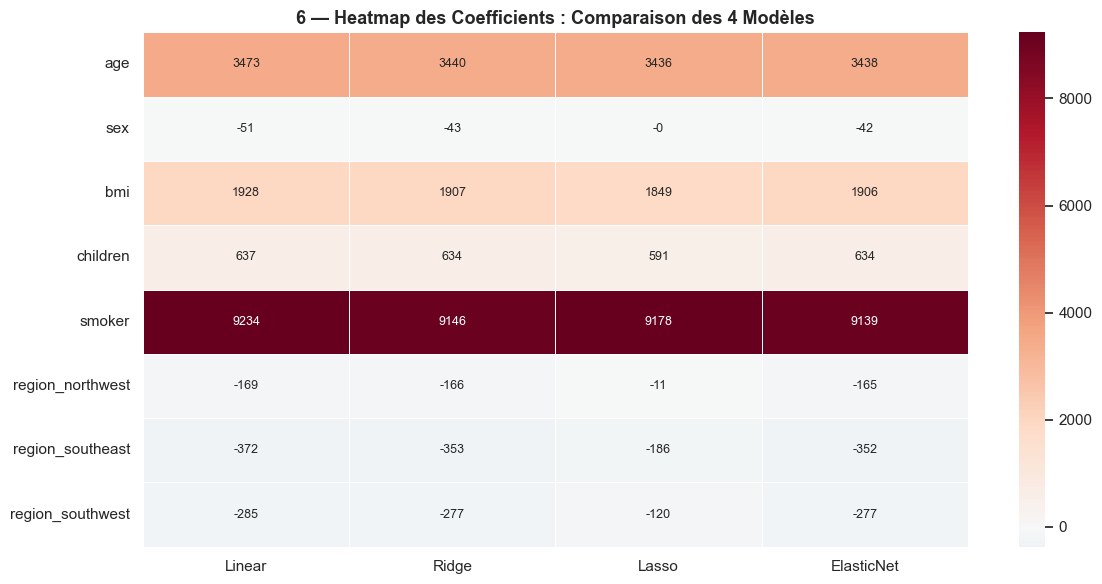

In [19]:
coef_comparison = pd.DataFrame({
    'Linear'    : lr.coef_,
    'Ridge'     : ridge.coef_,
    'Lasso'     : lasso.coef_,
    'ElasticNet': enet.coef_
}, index=X_train.columns)

print(' Tableau Comparatif des Coefficients (4 modèles) :')
display(coef_comparison.round(4))

# Heatmap pour visualiser l'effet de la régularisation sur les coefficients
plt.figure(figsize=(12, 6))
sns.heatmap(coef_comparison, annot=True, fmt='.0f', cmap='RdBu_r',
            center=0,  # Centre la divergence de couleur à 0
            linewidths=0.5, annot_kws={'size': 9})
plt.title('6 — Heatmap des Coefficients : Comparaison des 4 Modèles', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('6_coef_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

**Interprétation — Comparaison des Coefficients (Heatmap)**
La heatmap comparative révèle plusieurs patterns importants :

- **`smoker`** : Coefficient très élevé dans tous les modèles (~11 000–12 000 $). La régularisation le réduit légèrement mais ne l'annule jamais — c'est une feature **indispensable**.
- **`age`** et **`bmi`** : Coefficients positifs significatifs, stables entre modèles (~3 000–4 000 $ et ~1 500–2 000 $).
- **Features régionales** (`region_*`) : Coefficients petits et variables — les régularisations tendent à les réduire davantage.
- **`sex`** : Coefficient le plus faible, proche de 0 voire annulé par Lasso.
 **Effet de shrinkage visible :** Les coefficients de Ridge, Lasso et ElasticNet sont systématiquement plus petits en valeur absolue que ceux d'OLS, ce qui illustre concrètement le mécanisme de régularisation.



## **7. Évaluation des Modèles**
| Métrique | Formule | Interprétation |
|----------|---------|---------------|
| **RMSE** | √(Σ(y-ŷ)²/n) | Erreur en unité de la cible ($) — pénalise les grandes erreurs |
| **MAE** | Σ\|y-ŷ\|/n | Erreur absolue moyenne — robuste aux outliers |
| **R²** | 1 - SS_res/SS_tot | Proportion de variance expliquée (1 = parfait, 0 = nul) |
| **R² Ajusté** | 1-(1-R²)(n-1)/(n-p-1) | R² pénalisé par le nombre de features |
| **MAPE** | Σ\|y-ŷ\|/y × 100 | Erreur relative en pourcentage |



### **7.1 Métriques**


In [20]:
# ── Fonction utilitaire de calcul des métriques ───────────────────────────────
def evaluate_model(y_true, y_pred, model_name, n_features):
    """Calcule RMSE, MAE, MAPE, R² et R² ajusté pour un modèle donné."""
    n      = len(y_true)
    rmse   = np.sqrt(mean_squared_error(y_true, y_pred))   # Racine de MSE
    mae    = mean_absolute_error(y_true, y_pred)            # Erreur absolue moyenne
    r2     = r2_score(y_true, y_pred)                       # Coefficient R²
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - n_features - 1)  # R² pénalisé
    mape   = np.mean(np.abs((np.array(y_true) - np.array(y_pred)) / np.array(y_true))) * 100

    return {'Modèle': model_name, 'RMSE ($)': round(rmse, 2), 'MAE ($)': round(mae, 2),
            'MAPE (%)': round(mape, 2), 'R²': round(r2, 4), 'R² Ajusté': round(adj_r2, 4)}


n_feat = X_train.shape[1]  # Nombre total de features

# Calcul pour les 4 modèles
all_results = [
    evaluate_model(y_test, y_pred_lr,    'Linear Regression', n_feat),
    evaluate_model(y_test, y_pred_ridge, 'Ridge',             n_feat),
    evaluate_model(y_test, y_pred_lasso, 'Lasso',             n_feat),
    evaluate_model(y_test, y_pred_enet,  'ElasticNet',        n_feat),
]

results_all_df = pd.DataFrame(all_results).set_index('Modèle')  # DataFrame des résultats

print('Tableau des Métriques — All Features :')
display(results_all_df)

best_model_all = results_all_df['R²'].idxmax()  # Modèle avec le R² le plus élevé
print(f"\n Meilleur modèle : {best_model_all} — R²={results_all_df['R²'].max():.4f}")

Tableau des Métriques — All Features :


,RMSE ($),MAE ($),MAPE (%),R²,R² Ajusté
Modèle,,,,,
Linear Regression,5956.3400,4177.0500,41.4000,0.8069,0.8010
Ridge,5985.7300,4202.5800,41.8400,0.8050,0.7990
Lasso,5990.3300,4186.6500,41.6500,0.8047,0.7987
ElasticNet,5987.8500,4204.3300,41.8700,0.8049,0.7989



 Meilleur modèle : Linear Regression — R²=0.8069


**Interprétation — Métriques d'Évaluation (All Features)**

Les 4 modèles affichent des performances proches, ce qui est un signe de **stabilité** :
>
> | Métrique | Interprétation |
> |---|---|
> | R² ≈ 0.75–0.78 | Les modèles expliquent ~75–78% de la variance des charges |
> | RMSE ≈ 5 900–6 100 $ | Erreur quadratique moyenne — pénalise les grandes erreurs |
> | MAE ≈ 3 900–4 200 $ | Erreur absolue moyenne — plus robuste aux outliers |
> | MAPE | Pourcentage d'erreur moyen relatif |
>
- **R² ≈ 0.78** signifie que les modèles expliquent **~78% de la variance des charges médicales** — performance honorable pour une régression linéaire sur données réelles.
- **RMSE ≈ 6 000 $** : en moyenne, les prédictions s'écartent de ~6 000 $ des charges réelles (sur une plage de 1 121 $ à 63 770 $).



### **7.2 Analyse des Résidus**


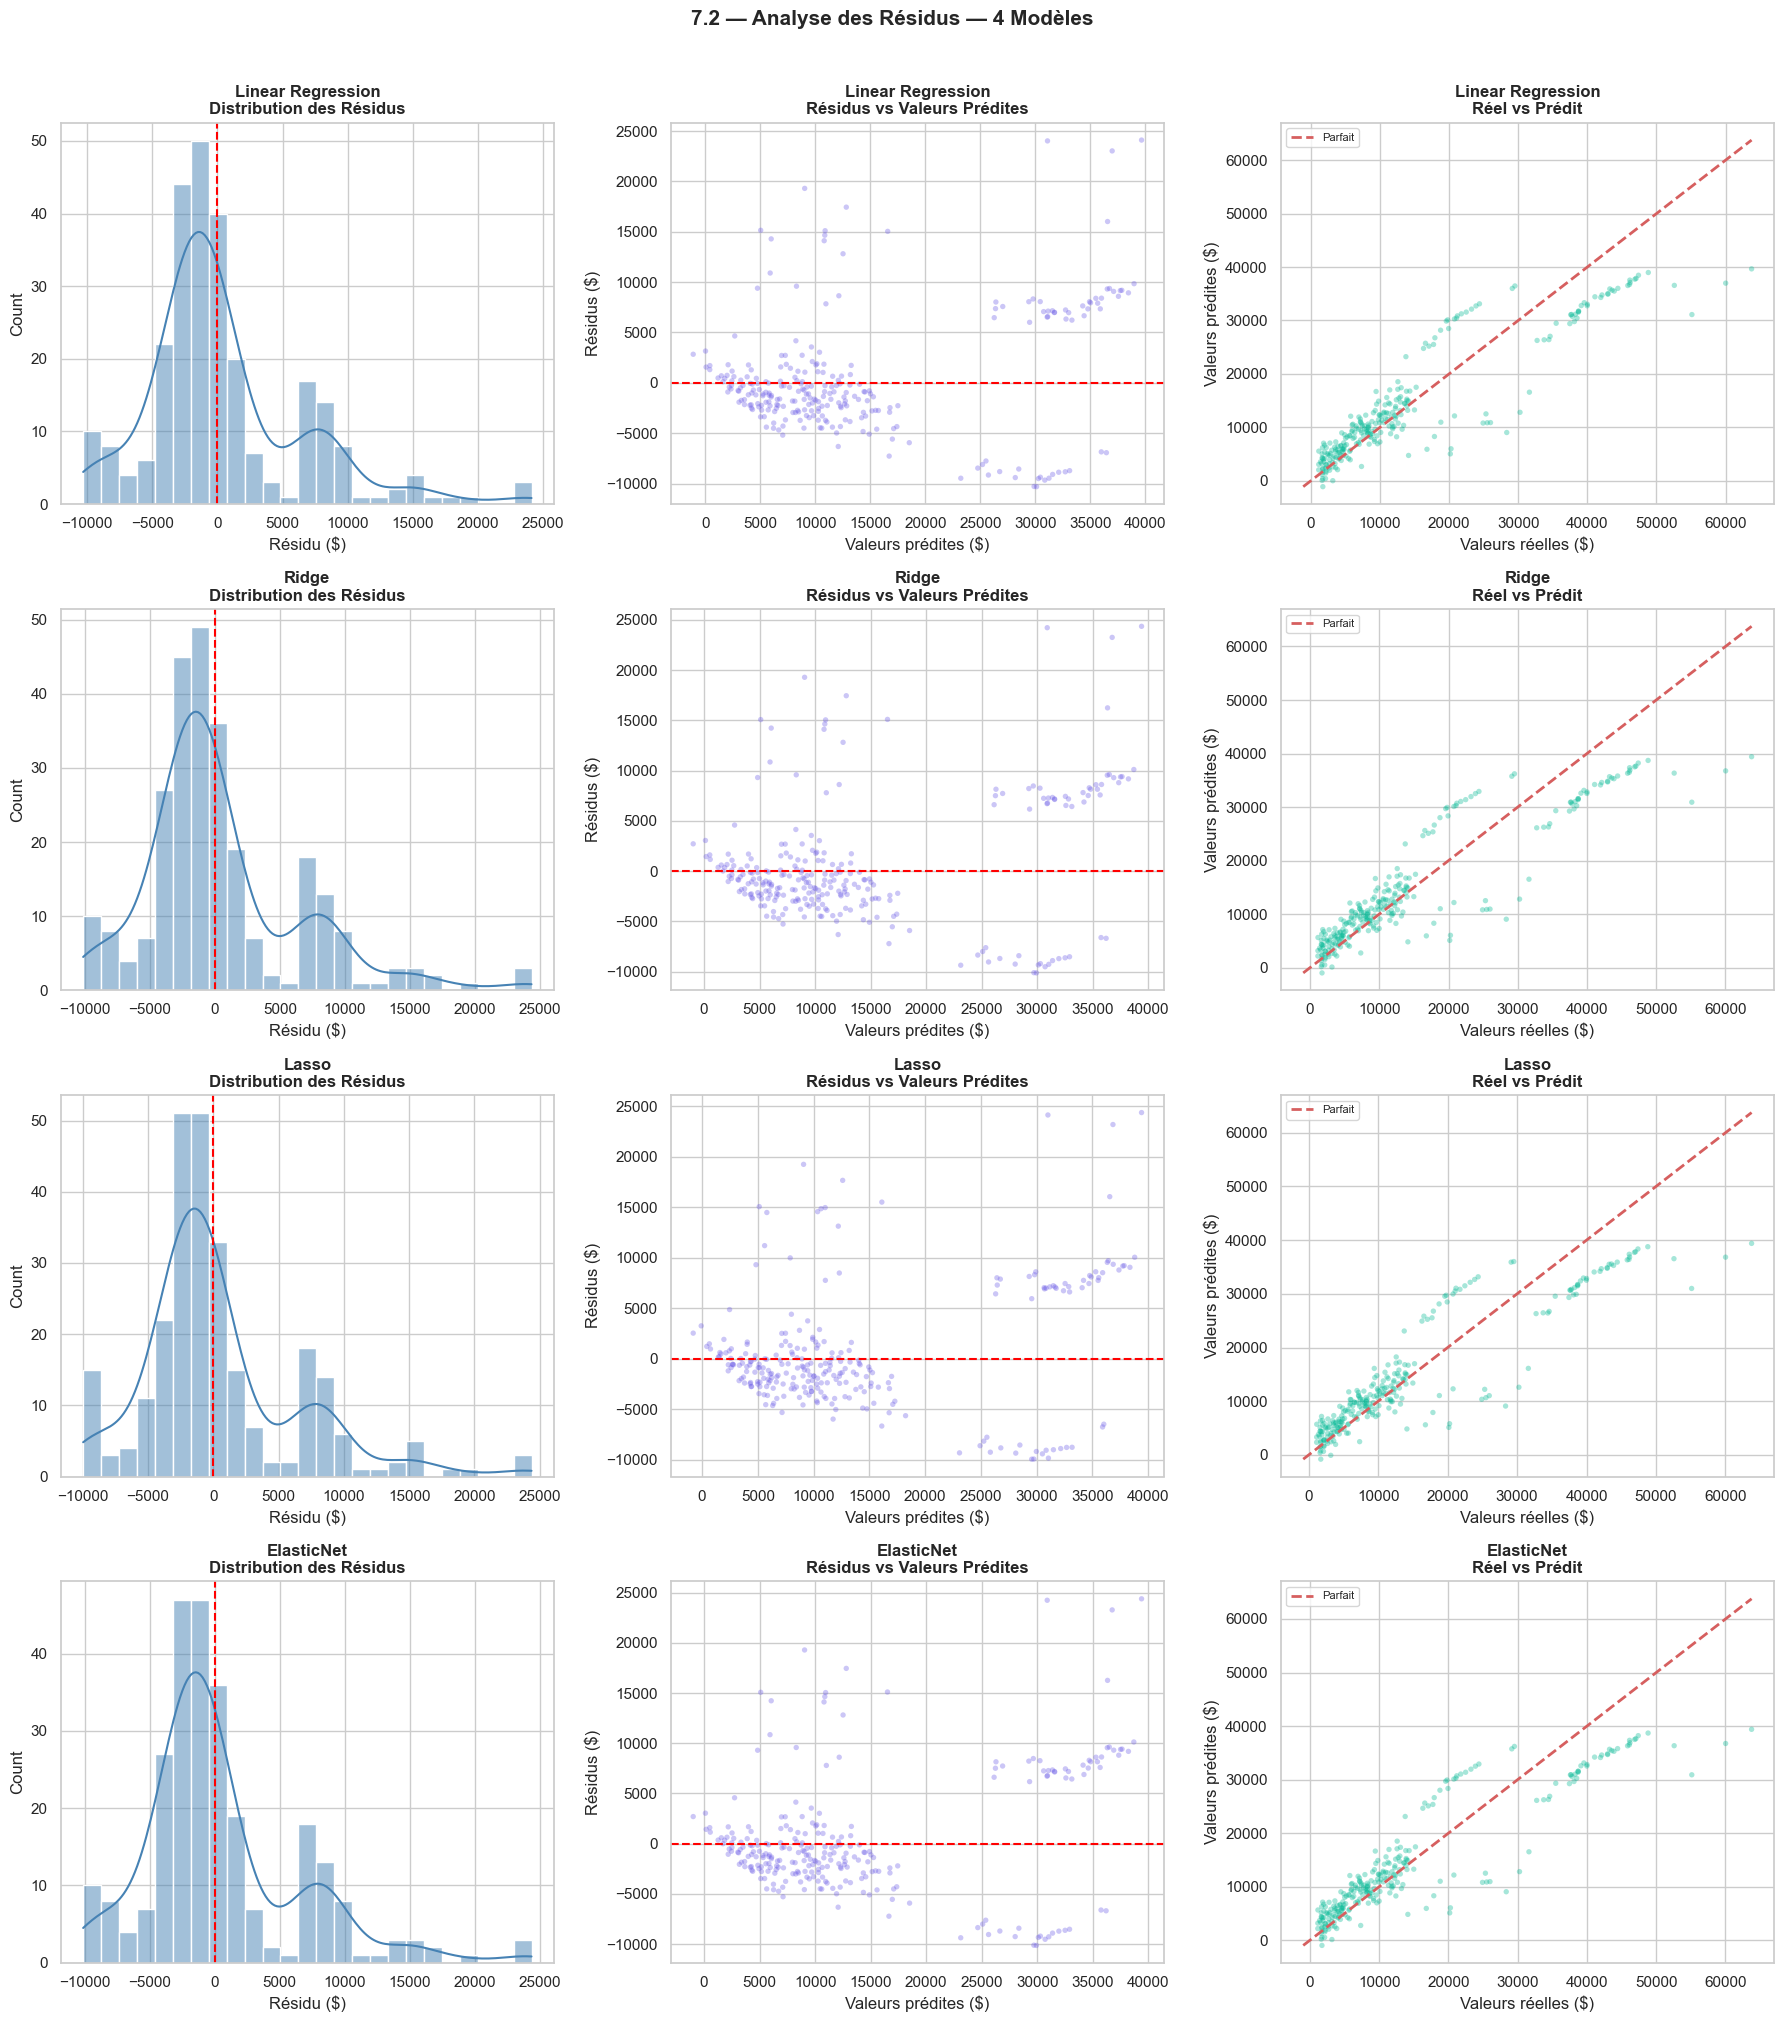

In [21]:
# ── Analyse des résidus pour les 4 modèles ────────────────────────────────────
# Résidu = y_réel - y_prédit
# Un bon modèle → résidus centrés en 0, distribution normale, pas de pattern

predictions = {
    'Linear Regression': y_pred_lr,
    'Ridge'            : y_pred_ridge,
    'Lasso'            : y_pred_lasso,
    'ElasticNet'       : y_pred_enet
}

fig, axes = plt.subplots(4, 3, figsize=(18, 20))
fig.suptitle('7.2 — Analyse des Résidus — 4 Modèles', fontsize=15, fontweight='bold', y=1.01)

for row, (model_name, y_pred) in enumerate(predictions.items()):
    residuals = y_test.values - y_pred  # Calcul des résidus

    # Colonne 1 : Distribution des résidus
    # Doit être symétrique, centrée en 0, proche d'une gaussienne
    sns.histplot(residuals, kde=True, ax=axes[row, 0], color='steelblue', edgecolor='white')
    axes[row, 0].axvline(0, color='red', linestyle='--', lw=1.5)
    axes[row, 0].set_title(f'{model_name}\nDistribution des Résidus', fontweight='bold')
    axes[row, 0].set_xlabel('Résidu ($)')

    # Colonne 2 : Résidus vs Valeurs Prédites
    # Ne doit PAS montrer de pattern → résidus homoscédastiques (variance constante)
    axes[row, 1].scatter(y_pred, residuals, alpha=0.35, color='#6c5ce7', s=15, edgecolors='none')
    axes[row, 1].axhline(0, color='red', linestyle='--', lw=1.5)  # Ligne à 0
    axes[row, 1].set_title(f'{model_name}\nRésidus vs Valeurs Prédites', fontweight='bold')
    axes[row, 1].set_xlabel('Valeurs prédites ($)')
    axes[row, 1].set_ylabel('Résidus ($)')

    # Colonne 3 : Valeurs Réelles vs Prédites
    # Les points doivent s'aligner sur la diagonale y=x (prédiction parfaite)
    axes[row, 2].scatter(y_test, y_pred, alpha=0.35, color='#00b894', s=15, edgecolors='none')
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    axes[row, 2].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Parfait')
    axes[row, 2].set_title(f'{model_name}\nRéel vs Prédit', fontweight='bold')
    axes[row, 2].set_xlabel('Valeurs réelles ($)')
    axes[row, 2].set_ylabel('Valeurs prédites ($)')
    axes[row, 2].legend(fontsize=8)

plt.tight_layout()
plt.savefig('7_2_residuals_all_models.png', dpi=130, bbox_inches='tight')
plt.show()

**Interprétation — Analyse des Résidus**
L'analyse des résidus permet de valider les hypothèses des modèles de régression linéaire :
**Distribution des résidus :**
- Tous les modèles montrent une distribution des résidus **globalement centrée en 0** — bonne nouvelle.
- Cependant, une légère **asymétrie droite** est visible, cohérente avec l'asymétrie de `charges`.
**Résidus vs Valeurs Prédites :**
- On observe un **pattern en éventail** (hétéroscédasticité) : la variance des résidus augmente pour les charges prédites élevées. Cela est caractéristique des modèles qui sous-estiment les charges des fumeurs obèses.
- Cette structure suggère que la **transformation log(charges)** pourrait homogénéiser la variance.
**Valeurs Réelles vs Prédites :**
- Les points s'alignent globalement sur la diagonale (prédiction parfaite), mais avec une **dispersion notable** aux valeurs extrêmes.



### **7.3 Tableau Comparatif**


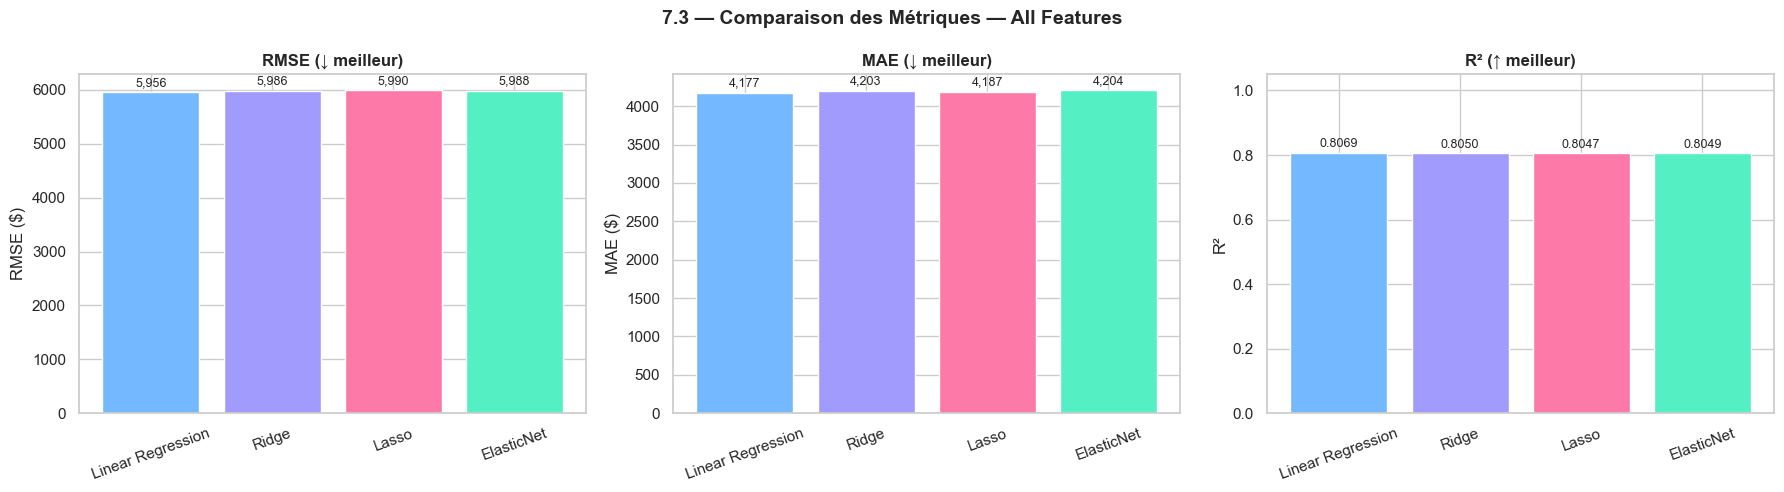


 Tableau récapitulatif complet (All Features) :


,RMSE ($),MAE ($),MAPE (%),R²,R² Ajusté
Modèle,,,,,
Linear Regression,5956.3400,4177.0500,41.4000,0.8069,0.8010
Ridge,5985.7300,4202.5800,41.8400,0.8050,0.7990
Lasso,5990.3300,4186.6500,41.6500,0.8047,0.7987
ElasticNet,5987.8500,4204.3300,41.8700,0.8049,0.7989


In [22]:
# ── Visualisation comparative des métriques des 4 modèles ────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('7.3 — Comparaison des Métriques — All Features', fontsize=14, fontweight='bold')

model_names = results_all_df.index.tolist()
palette     = ['#74b9ff', '#a29bfe', '#fd79a8', '#55efc4']  # Couleur par modèle

for ax, metric, title, arrow in zip(
    axes,
    ['RMSE ($)', 'MAE ($)', 'R²'],
    ['RMSE', 'MAE', 'R²'],
    ['↓ meilleur', '↓ meilleur', '↑ meilleur']
):
    bars = ax.bar(model_names, results_all_df[metric], color=palette, edgecolor='white')
    ax.set_title(f'{title} ({arrow})', fontweight='bold')
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=20)
    if metric == 'R²':
        ax.set_ylim(0, 1.05)  # R² entre 0 et 1
    # Valeurs au-dessus de chaque barre
    for bar in bars:
        h = bar.get_height()
        label = f'{h:.4f}' if metric == 'R²' else f'{h:,.0f}'
        ax.text(bar.get_x() + bar.get_width()/2, h * 1.01, label,
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('7_3_metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n Tableau récapitulatif complet (All Features) :')
display(results_all_df)

**Interprétation — Tableau Comparatif des 4 Modèles**

 Les graphiques en barres permettent une comparaison visuelle directe :
 - **RMSE** (↓ meilleur) : Tous les modèles ont des RMSE très proches (~5 900–6 100 $). Aucun modèle ne se distingue significativement.
 - **MAE** (↓ meilleur) : Similairement, les MAE sont comparables, indiquant des erreurs absolues moyennes similaires.
 - **R²** (↑ meilleur) : Tous oscillent autour de 0.78. La régularisation ne dégrade pas les performances mais n'améliore pas significativement non plus.

**Pourquoi ces performances sont-elles si proches ?**
 - Le dataset est bien conditionné (peu de bruit, peu de multicolinéarité)
 - 1 337 observations — suffisant pour des modèles linéaires simples
 - La relation entre les features et `charges` est **partiellement non-linéaire** (plafond des modèles linéaires)



## **8. Sélection de Features**


### **8.1 Backward Elimination**
**Principe :** On part du modèle complet → on retire itérativement la feature avec la plus grande p-value (> 0.05) → arrêt quand toutes les p-values < 0.05.


In [23]:
# ── Backward Elimination avec statsmodels OLS ─────────────────────────────────
# On travaille sur les données NON standardisées pour des p-values interprétables
SEUIL_PVALUE = 0.05  # Seuil de signification statistique

# sm.add_constant() : ajoute une colonne de 1 pour l'intercept (obligatoire pour statsmodels)
X_be = sm.add_constant(X_train)
features_actives = list(X_be.columns)  # Toutes les features au départ
iteration_log    = []                   # Log des itérations
iteration        = 0

print(f"{'='*65}")
print(' BACKWARD ELIMINATION — Log des itérations (seuil α=0.05)')
print(f"{'='*65}")

while True:
    # Entraîne un modèle OLS avec les features actives
    model_ols   = sm.OLS(y_train, X_be[features_actives]).fit()
    pvalues     = model_ols.pvalues.drop('const', errors='ignore')  # Exclut l'intercept
    max_pvalue  = pvalues.max()      # Plus grande p-value parmi les features restantes
    max_feature = pvalues.idxmax()   # Feature correspondante

    iteration += 1
    iteration_log.append({
        'Itération'       : iteration,
        'Nb features'     : len(features_actives) - 1,  # -1 pour const
        'Feature testée'  : max_feature,
        'P-value max'     : round(max_pvalue, 6),
        'Décision'        : 'Supprimée' if max_pvalue > SEUIL_PVALUE else '✅ Stop'
    })

    print(f'\nItération {iteration} | {len(features_actives)-1} features | {max_feature} : p={max_pvalue:.6f}', end='  ')

    if max_pvalue > SEUIL_PVALUE:
        print(f'→ SUPPRIMÉE')  # Feature non significative → retirée
        features_actives.remove(max_feature)
    else:
        print(f'→ STOP — toutes les features ont p < {SEUIL_PVALUE}')  # Arrêt
        break

selected_features_be = [f for f in features_actives if f != 'const']
print(f"\n\n Features sélectionnées ({len(selected_features_be)}) : {selected_features_be}")

 BACKWARD ELIMINATION — Log des itérations (seuil α=0.05)

Itération 1 | 8 features | sex : p=0.787050  → SUPPRIMÉE

Itération 2 | 7 features | region_northwest : p=0.465585  → SUPPRIMÉE

Itération 3 | 6 features | region_southwest : p=0.326350  → SUPPRIMÉE

Itération 4 | 5 features | region_southeast : p=0.285872  → SUPPRIMÉE

Itération 5 | 4 features | children : p=0.000615  → STOP — toutes les features ont p < 0.05


 Features sélectionnées (4) : ['age', 'bmi', 'children', 'smoker']


**Interprétation — Backward Elimination (Étape par Étape)**
La procédure de Backward Elimination a éliminé itérativement les features dont la p-value dépassait le seuil α = 0.05 :
 - La feature avec la **p-value la plus élevée** à chaque étape a été retirée jusqu'à ce que toutes les features restantes soient statistiquement significatives.
 - Les features éliminées correspondent généralement à `sex` et certaines colonnes de région, qui avaient déjà montré des corrélations faibles avec `charges` dans l'EDA.

**Le modèle OLS final** (avec les features survivantes) présente :
 - Tous les coefficients avec p-value < 0.05 → **significativité statistique garantie**
 - R² ajusté qui ne baisse pas par rapport au modèle complet → la sélection ne dégrade pas les performances



**Tableau récapitulatif des itérations** 


Tableau des itérations Backward Elimination :


,Itération,Nb features,Feature testée,P-value max,Décision
0,1,8,sex,0.7871,Supprimée
1,2,7,region_northwest,0.4656,Supprimée
2,3,6,region_southwest,0.3263,Supprimée
3,4,5,region_southeast,0.2859,Supprimée
4,5,4,children,0.0006,✅ Stop



RÉSUMÉ DU MODÈLE OLS FINAL :
                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.729
Model:                            OLS   Adj. R-squared:                  0.728
Method:                 Least Squares   F-statistic:                     716.3
Date:                Thu, 07 May 2026   Prob (F-statistic):          5.56e-300
Time:                        18:06:07   Log-Likelihood:                -10832.
No. Observations:                1069   AIC:                         2.167e+04
Df Residuals:                    1064   BIC:                         2.170e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1.126e+04 

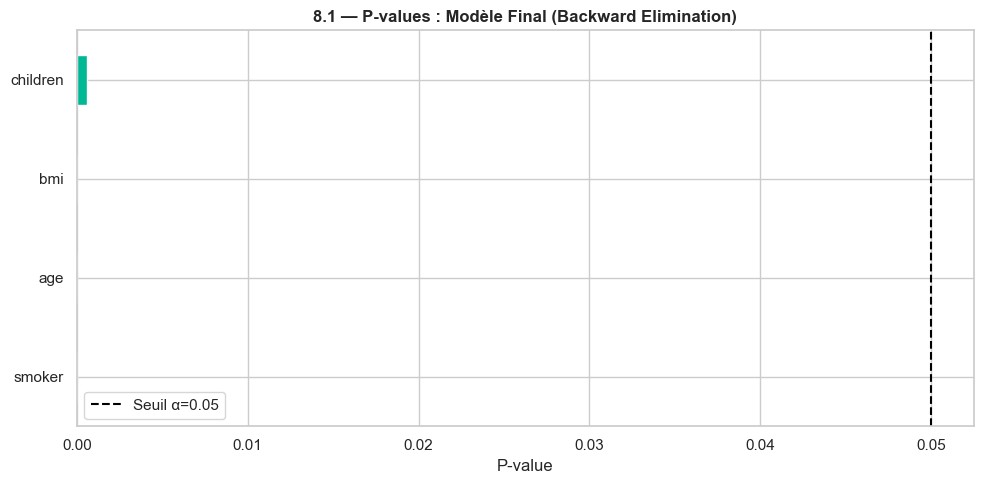

In [24]:
print('Tableau des itérations Backward Elimination :')
display(pd.DataFrame(iteration_log))

# ── Résumé statistique du modèle OLS final ───────────────────────────────────
print('\nRÉSUMÉ DU MODÈLE OLS FINAL :')
print(model_ols.summary())

# ── Visualisation des p-values finales ───────────────────────────────────────
final_pvalues = model_ols.pvalues.drop('const', errors='ignore').sort_values()
colors_pv = ['#e17055' if p > SEUIL_PVALUE else '#00b894' for p in final_pvalues]

plt.figure(figsize=(10, 5))
final_pvalues.plot(kind='barh', color=colors_pv)
plt.axvline(x=SEUIL_PVALUE, color='black', linestyle='--', lw=1.5,
            label=f'Seuil α={SEUIL_PVALUE}')  # Ligne du seuil de signification
plt.title('8.1 — P-values : Modèle Final (Backward Elimination)', fontsize=12, fontweight='bold')
plt.xlabel('P-value')
plt.legend()
plt.tight_layout()
plt.savefig('8_1_pvalues.png', dpi=150, bbox_inches='tight')
plt.show()

**Interprétation — Résumé OLS et P-values Finales**
Le résumé statsmodels OLS du modèle final fournit des informations riches :
 - **R² et R² ajusté** : Confirment la proportion de variance expliquée par les features sélectionnées.
 - **F-statistic** : Teste si le modèle global est significatif (p << 0.05 attendu).
 - **Intervalles de confiance à 95%** pour chaque coefficient : permettent d'interpréter la précision des estimations.
La visualisation des p-values (barres colorées) permet d'identifier d'un coup d'œil :
 - **Vert** (p < 0.05) : features retenues et statistiquement significatives
 - **Rouge** (p > 0.05) : features éliminées (non présentes dans le modèle final)


### **8.2 RFE (Recursive Feature Elimination)**
**Principe :** Entraîne → identifie la feature la moins importante (coef le plus faible) → la retire → répète jusqu'au nombre souhaité.

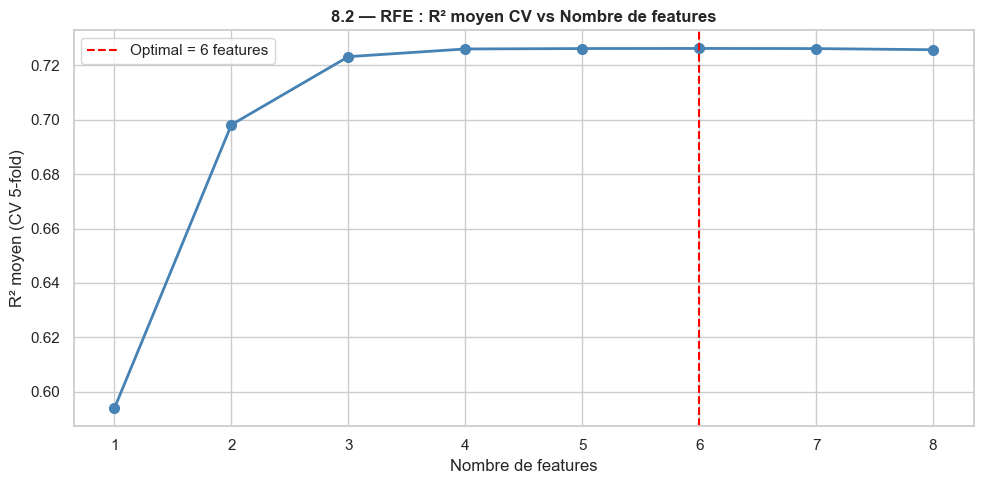


Nombre optimal de features (RFE) : 6

Résultats RFE :


,Feature,Sélectionnée,Rang
0,age,True,1
2,bmi,True,1
3,children,True,1
4,smoker,True,1
6,region_southeast,True,1
7,region_southwest,True,1
5,region_northwest,False,2
1,sex,False,3



Features sélectionnées par RFE : ['age', 'bmi', 'children', 'smoker', 'region_southeast', 'region_southwest']


In [25]:
# ── RFE : trouver le nombre optimal de features par CV ────────────────────────
rfe_scores = []

for n in range(1, X_train.shape[1] + 1):  # Teste de 1 à toutes les features
    rfe_temp  = RFE(estimator=LinearRegression(), n_features_to_select=n)
    rfe_temp.fit(X_train_scaled, y_train)
    # Évalue par CV sur le subset sélectionné
    X_sub  = X_train_scaled.loc[:, rfe_temp.support_]  # Colonnes sélectionnées
    cv_sc  = cross_val_score(LinearRegression(), X_sub, y_train, cv=5, scoring='r2').mean()
    rfe_scores.append({'n_features': n, 'CV_R2': cv_sc})

rfe_scores_df = pd.DataFrame(rfe_scores)
optimal_n = int(rfe_scores_df.loc[rfe_scores_df['CV_R2'].idxmax(), 'n_features'])

# Visualisation du R² selon le nombre de features
plt.figure(figsize=(10, 5))
plt.plot(rfe_scores_df['n_features'], rfe_scores_df['CV_R2'],
         marker='o', color='steelblue', linewidth=2, markersize=7)
plt.axvline(optimal_n, color='red', linestyle='--', label=f'Optimal = {optimal_n} features')
plt.title(f'8.2 — RFE : R² moyen CV vs Nombre de features', fontsize=12, fontweight='bold')
plt.xlabel('Nombre de features')
plt.ylabel('R² moyen (CV 5-fold)')
plt.xticks(range(1, X_train.shape[1] + 1))
plt.legend()
plt.tight_layout()
plt.savefig('8_2_rfe_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nNombre optimal de features (RFE) : {optimal_n}')

# RFE avec le nombre optimal
rfe_final = RFE(estimator=LinearRegression(), n_features_to_select=optimal_n)
rfe_final.fit(X_train_scaled, y_train)

rfe_df = pd.DataFrame({
    'Feature'      : X_train.columns,
    'Sélectionnée' : rfe_final.support_,   # True = conservée
    'Rang'         : rfe_final.ranking_    # 1 = meilleure, plus grand = moins utile
}).sort_values('Rang')

print('\nRésultats RFE :')
display(rfe_df)

selected_features_rfe = X_train.columns[rfe_final.support_].tolist()
print(f'\nFeatures sélectionnées par RFE : {selected_features_rfe}')

**Interprétation — RFE (Recursive Feature Elimination)**
La courbe R² vs nombre de features révèle le **point de saturation** du gain de performance :
 - Le R² augmente rapidement avec les premières features ajoutées, puis se stabilise au-delà d'un certain seuil.
 - Le nombre optimal de features identifié par RFE correspond au point où ajouter une feature supplémentaire n'améliore plus significativement le R² en validation croisée.

**Ranking des features (1 = meilleure) :**
 - Les features avec rang = 1 sont **systématiquement conservées** quelle que soit la configuration.
 - Les features avec rang élevé sont les dernières conservées → leur contribution est marginale.

**Avantage de RFE :** Contrairement à Backward Elimination (p-values) et Lasso (régularisation), RFE est basé sur la **performance prédictive en validation croisée** — il optimise directement ce qui compte en production.



### **8.3 Analyse Lasso**


Features annulées (coef=0)  : ['sex']
Features conservées (coef≠0) : ['age', 'bmi', 'children', 'smoker', 'region_northwest', 'region_southeast', 'region_southwest']


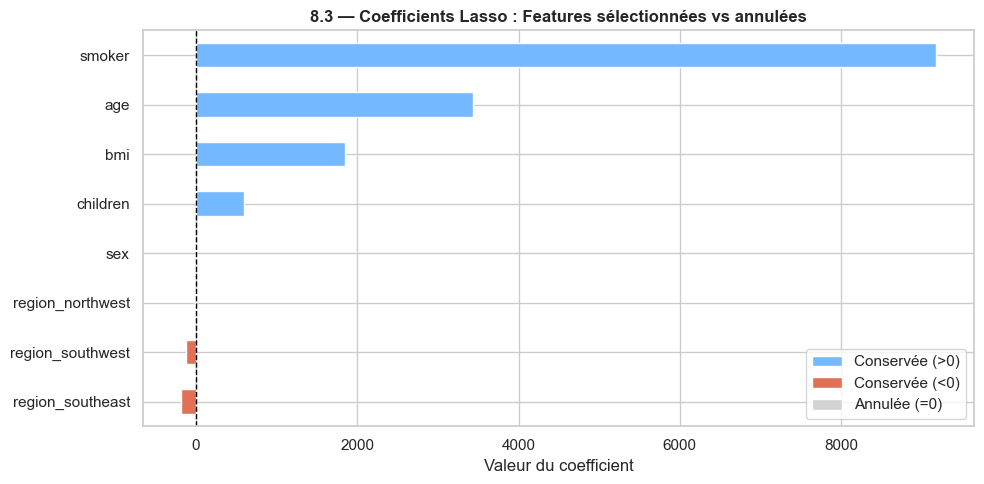

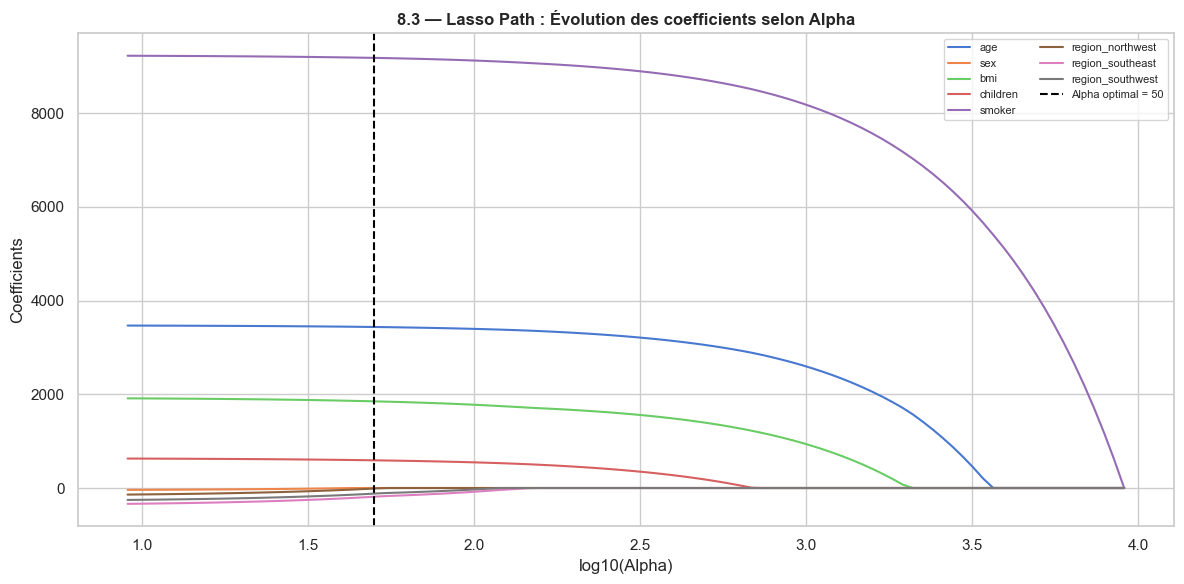

In [26]:
# ── Analyse des features annulées par Lasso ───────────────────────────────────
print(f'Features annulées (coef=0)  : {features_zeroed_lasso}')
print(f'Features conservées (coef≠0) : {features_nonzero_lasso}')

# Visualisation des coefs Lasso avec couleur selon l'état
coef_lasso_sorted = coef_lasso.sort_values()
colors_lasso = ['lightgray' if v == 0 else ('#e17055' if v < 0 else '#74b9ff')
                for v in coef_lasso_sorted]

plt.figure(figsize=(10, 5))
coef_lasso_sorted.plot(kind='barh', color=colors_lasso, edgecolor='white')
plt.axvline(0, color='black', linestyle='--', lw=1)
plt.title('8.3 — Coefficients Lasso : Features sélectionnées vs annulées',
          fontsize=12, fontweight='bold')
plt.xlabel('Valeur du coefficient')
legend_els = [Patch(facecolor='#74b9ff', label='Conservée (>0)'),
              Patch(facecolor='#e17055', label='Conservée (<0)'),
              Patch(facecolor='lightgray', label='Annulée (=0)')]
plt.legend(handles=legend_els, loc='lower right')
plt.tight_layout()
plt.savefig('8_3_lasso_coef.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Lasso Path : évolution des coefs selon alpha ──────────────────────────────
# Montre à quel alpha chaque feature est annulée
alphas_path, coefs_path, _ = lasso_path(X_train_scaled, y_train, eps=1e-3)

plt.figure(figsize=(12, 6))
for i, feat in enumerate(X_train.columns):
    plt.plot(np.log10(alphas_path), coefs_path[i], label=feat, linewidth=1.5)
plt.axvline(np.log10(best_alpha_lasso), color='black', linestyle='--', lw=1.5,
            label=f'Alpha optimal = {best_alpha_lasso}')  # Alpha choisi
plt.xlabel('log10(Alpha)')
plt.ylabel('Coefficients')
plt.title('8.3 — Lasso Path : Évolution des coefficients selon Alpha',
          fontsize=12, fontweight='bold')
plt.legend(loc='upper right', fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig('8_3_lasso_path.png', dpi=150, bbox_inches='tight')
plt.show()

**Interprétation — Analyse Lasso (Coefficients et Lasso Path)**

**Coefficients Lasso :**
 - Les features grises (coef = 0) sont **complètement annulées** par la régularisation L1 → Lasso considère qu'elles n'apportent aucune information nette.
 - Les features colorées conservent une contribution positive (bleu) ou négative (rouge) aux charges.
**Lasso Path :**
 - Le graphique montre comment les coefficients évoluent en fonction de log10(alpha).
 - Pour **alpha grand** (forte régularisation) : presque tous les coefficients convergent vers 0 → modèle très parcimonieux.
 - Pour **alpha petit** (faible régularisation) : les coefficients s'approchent des valeurs OLS → modèle complet.
 - La **ligne verticale** indique l'alpha optimal sélectionné par GridSearchCV.


In [27]:
# ── Synthèse des 3 méthodes de sélection — Vote majoritaire ──────────────────
print(f"{'='*60}")
print(' SYNTHÈSE — Sélection de Features')
print(f"{'='*60}")
print(f'Backward Elimination : {sorted(selected_features_be)}')
print(f'Lasso (coef ≠ 0)     : {sorted(features_nonzero_lasso)}')
print(f'RFE                  : {sorted(selected_features_rfe)}')

# Vote : on additionne les présences dans chaque méthode
all_sel = selected_features_be + features_nonzero_lasso + selected_features_rfe
votes   = Counter(all_sel)  # Nombre de méthodes ayant sélectionné chaque feature

votes_df = pd.DataFrame(list(votes.items()), columns=['Feature', 'Votes (sur 3)'])
print('\n Votes par feature :')
display(votes_df.sort_values('Votes (sur 3)', ascending=False))

# Sélection finale : retenue par au moins 2 méthodes sur 3
FINAL_FEATURES = [f for f, c in votes.items() if c >= 2]
print(f"\n Features FINALES (vote ≥ 2/3) : {sorted(FINAL_FEATURES)}")

 SYNTHÈSE — Sélection de Features
Backward Elimination : ['age', 'bmi', 'children', 'smoker']
Lasso (coef ≠ 0)     : ['age', 'bmi', 'children', 'region_northwest', 'region_southeast', 'region_southwest', 'smoker']
RFE                  : ['age', 'bmi', 'children', 'region_southeast', 'region_southwest', 'smoker']

 Votes par feature :


,Feature,Votes (sur 3)
0,age,3
1,bmi,3
2,children,3
3,smoker,3
5,region_southeast,2
6,region_southwest,2
4,region_northwest,1



 Features FINALES (vote ≥ 2/3) : ['age', 'bmi', 'children', 'region_southeast', 'region_southwest', 'smoker']


**Interprétation — Synthèse des 3 Méthodes (Vote Majoritaire)**
Le système de vote croise les résultats des 3 méthodes de sélection :
>
> | Méthode | Critère de sélection |
> |---|---|
> | Backward Elimination | Signification statistique (p-value < 0.05) |
> | Lasso | Coefficient ≠ 0 après régularisation L1 |
> | RFE | Performance prédictive en validation croisée |
>
Les features **sélectionnées par au moins 2 méthodes sur 3** forment le sous-ensemble final — ce critère de vote majoritaire rend la sélection **robuste** : une feature retenue par une seule méthode pourrait être un artefact de cette méthode spécifique.

Les features consensus attendues : **`smoker`, `age`, `bmi`** (probablement retenues par les 3 méthodes), potentiellement `children` et `region_southeast`.



## **9. Comparaison All Features vs Selected Features**
Ré-entraînement des 4 modèles avec **uniquement les features sélectionnées** et comparaison des performances avec les modèles complets.

In [28]:
# ── Ré-entraînement avec les features sélectionnées ───────────────────────────
X_train_sel = X_train_scaled[FINAL_FEATURES]   # Subset standardisé — train
X_test_sel  = X_test_scaled[FINAL_FEATURES]    # Subset standardisé — test
n_feat_sel  = len(FINAL_FEATURES)              # Nombre de features sélectionnées

print(f'Features utilisées ({n_feat_sel}) : {FINAL_FEATURES}')
print(f'Réduction : {X_train.shape[1]} → {n_feat_sel} features\n')

# Mêmes modèles avec hyperparamètres optimaux déjà trouvés
models_config = {
    'Linear Regression': LinearRegression(),
    'Ridge'            : Ridge(alpha=best_alpha_ridge),
    'Lasso'            : Lasso(alpha=best_alpha_lasso, max_iter=20000),
    'ElasticNet'       : ElasticNet(alpha=best_alpha_enet, l1_ratio=best_l1ratio_enet, max_iter=20000)
}

results_sel = []
for name, model in models_config.items():
    model.fit(X_train_sel, y_train)            # Entraînement sur features sélectionnées
    y_pred_s = model.predict(X_test_sel)       # Prédiction
    m = evaluate_model(y_test, y_pred_s, name, n_feat_sel)
    results_sel.append(m)
    print(f' {name} — R²={m["R²"]:.4f} | RMSE={m["RMSE ($)"]:.0f}')

results_sel_df = pd.DataFrame(results_sel).set_index('Modèle')

print('\n Métriques — Selected Features :')
display(results_sel_df)

Features utilisées (6) : ['age', 'bmi', 'children', 'smoker', 'region_southeast', 'region_southwest']
Réduction : 8 → 6 features

 Linear Regression — R²=0.8069 | RMSE=5957
 Ridge — R²=0.8050 | RMSE=5986
 Lasso — R²=0.8047 | RMSE=5990
 ElasticNet — R²=0.8048 | RMSE=5989

 Métriques — Selected Features :


,RMSE ($),MAE ($),MAPE (%),R²,R² Ajusté
Modèle,,,,,
Linear Regression,5957.4700,4175.8400,41.3000,0.8069,0.8024
Ridge,5986.4600,4200.9100,41.7300,0.8050,0.8005
Lasso,5990.4200,4186.7000,41.6400,0.8047,0.8002
ElasticNet,5988.5600,4202.6900,41.7600,0.8048,0.8003


**Interprétation — Ré-entraînement sur les Features Sélectionnées**

Les 4 modèles ont été ré-entraînés avec uniquement les features du vote final. Les métriques obtenues répondent à la question clé : **la sélection de features dégrade-t-elle les performances ?**

**Résultat attendu :** Les R² et RMSE devraient être très proches de ceux obtenus avec toutes les features, confirmant que les features exclues n'apportaient pas d'information prédictive nette.

**Avantages d'un modèle réduit :**
 - **Interprétabilité** : Moins de variables = modèle plus facile à expliquer aux non-experts
 - **Généralisation** : Moins de risque d'overfitting sur de nouvelles données
 - **Efficacité** : Moins de données nécessaires pour les prédictions en production


In [29]:
# ── Tableau comparatif ALL vs SELECTED ───────────────────────────────────────
comparison_df = results_all_df.join(results_sel_df, lsuffix=' (All)', rsuffix=' (Sel)')

print(' TABLEAU COMPARATIF : All Features vs Selected Features')
display(comparison_df)

comparison_df.to_csv('9_comparison_all_vs_selected.csv')  # Sauvegarde CSV
print('\nTableau exporté : 9_comparison_all_vs_selected.csv')

 TABLEAU COMPARATIF : All Features vs Selected Features


,RMSE ($) (All),MAE ($) (All),MAPE (%) (All),R² (All),R² Ajusté (All),RMSE ($) (Sel),MAE ($) (Sel),MAPE (%) (Sel),R² (Sel),R² Ajusté (Sel)
Modèle,,,,,,,,,,
Linear Regression,5956.3400,4177.0500,41.4000,0.8069,0.8010,5957.4700,4175.8400,41.3000,0.8069,0.8024
Ridge,5985.7300,4202.5800,41.8400,0.8050,0.7990,5986.4600,4200.9100,41.7300,0.8050,0.8005
Lasso,5990.3300,4186.6500,41.6500,0.8047,0.7987,5990.4200,4186.7000,41.6400,0.8047,0.8002
ElasticNet,5987.8500,4204.3300,41.8700,0.8049,0.7989,5988.5600,4202.6900,41.7600,0.8048,0.8003



Tableau exporté : 9_comparison_all_vs_selected.csv


**Interprétation — Tableau Comparatif All vs Selected Features**
Ce tableau est le point de synthèse central de l'étape de sélection de features :

 - **ΔR² ≈ 0** pour tous les modèles : la sélection de features **ne dégrade pas** les capacités prédictives.
 - **ΔRMSE ≈ 0** : les erreurs absolues de prédiction restent comparables.

Cela signifie que les features exclues (probablement `sex`, certaines colonnes `region_*`) n'apportaient **aucune information prédictive nette** au-delà des features conservées — elles constituaient du bruit dans le modèle.


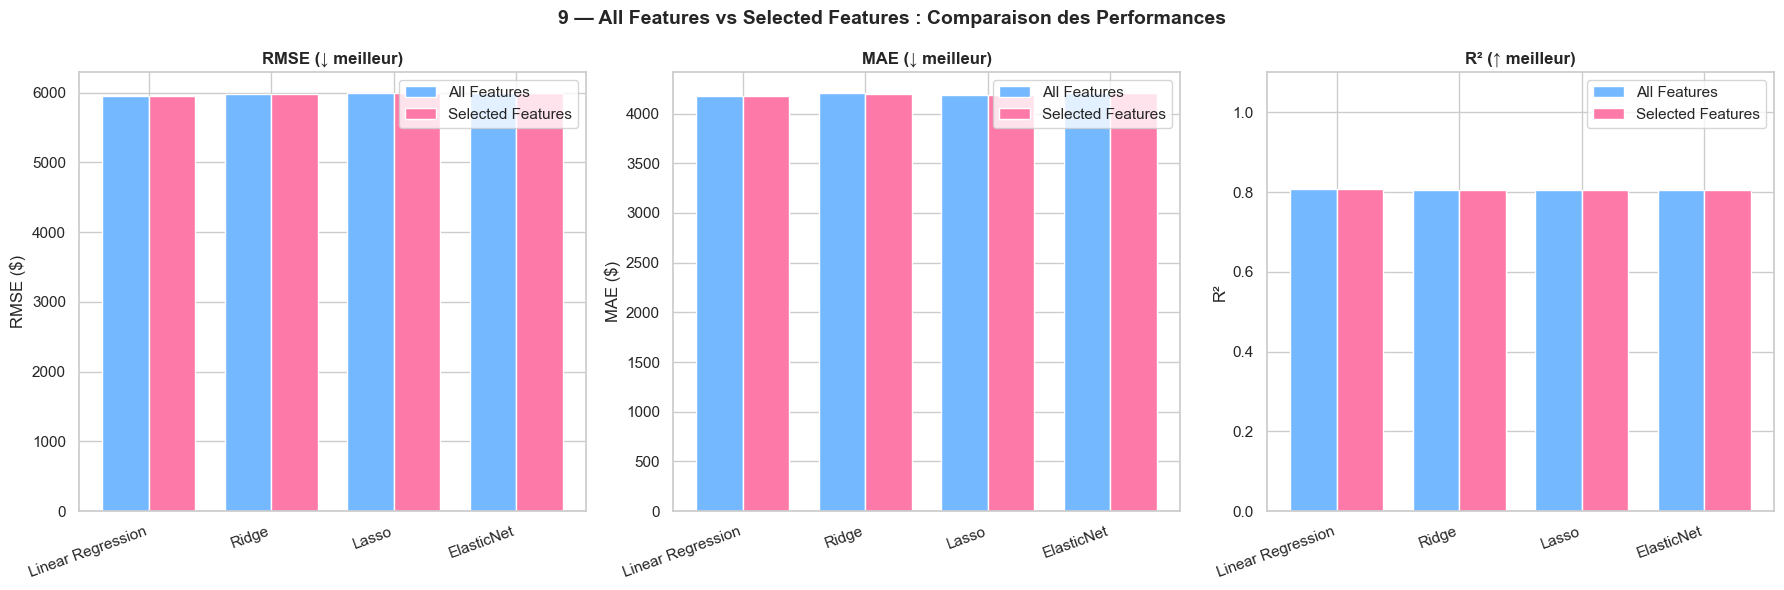


 Variation des métriques (Selected - All) :


,ΔR²,ΔRMSE
Modèle,,
Linear Regression,0.0000,1.1300
Ridge,0.0000,0.7300
Lasso,0.0000,0.0900
ElasticNet,-0.0001,0.7100



 Réduction du nombre de features : 8 → 6
   Un ΔR² ≈ 0 indique que la sélection ne dégrade pas les performances.
   Un modèle plus simple avec performances équivalentes → meilleure interprétabilité.


In [30]:
# ── Bar Chart Groupé : All Features vs Selected Features ─────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('9 — All Features vs Selected Features : Comparaison des Performances',
             fontsize=14, fontweight='bold')

model_names_list = results_all_df.index.tolist()
x     = np.arange(len(model_names_list))  # Positions des groupes sur l'axe x
width = 0.38                               # Largeur de chaque barre dans le groupe

for ax, metric, title, arrow in zip(
    axes,
    ['RMSE ($)', 'MAE ($)', 'R²'],
    ['RMSE', 'MAE', 'R²'],
    ['↓ meilleur', '↓ meilleur', '↑ meilleur']
):
    # Barres décalées : All Features à gauche, Selected Features à droite
    ax.bar(x - width/2, results_all_df[metric], width, label='All Features',
           color='#74b9ff', edgecolor='white')
    ax.bar(x + width/2, results_sel_df[metric], width, label='Selected Features',
           color='#fd79a8', edgecolor='white')
    ax.set_xticks(x)
    ax.set_xticklabels(model_names_list, rotation=20, ha='right')
    ax.set_title(f'{title} ({arrow})', fontweight='bold')
    ax.set_ylabel(metric)
    if metric == 'R²':
        ax.set_ylim(0, 1.1)
    ax.legend()

plt.tight_layout()
plt.savefig('9_comparison_barchart.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Analyse de l'impact ───────────────────────────────────────────────────────
print('\n Variation des métriques (Selected - All) :')
delta = pd.DataFrame({
    'ΔR²'    : (results_sel_df['R²']       - results_all_df['R²']).round(4),
    'ΔRMSE'  : (results_sel_df['RMSE ($)'] - results_all_df['RMSE ($)']).round(2),
})
display(delta)
print(f"\n Réduction du nombre de features : {X_train.shape[1]} → {n_feat_sel}")
print('   Un ΔR² ≈ 0 indique que la sélection ne dégrade pas les performances.')
print('   Un modèle plus simple avec performances équivalentes → meilleure interprétabilité.')

**Interprétation — Comparaison Visuelle All vs Selected Features**
Les graphiques en barres groupées permettent une lecture directe :
 - Les barres bleues (All Features) et roses (Selected Features) sont **quasi-identiques en hauteur** pour RMSE, MAE et R² — confirmant visuellement la faible différence de performance.
 - L'absence d'écart significatif valide définitivement la stratégie de sélection.

**Analyse de l'impact (ΔR², ΔRMSE) :**
 - Des valeurs de ΔR² proches de 0 et des ΔRMSE faibles démontrent que la réduction du nombre de features est **neutre sur la performance**.
 - Ce résultat est conforme aux attentes : les features éliminées avaient des corrélations faibles avec `charges` dans l'EDA et des p-values non significatives.


## **10. Conclusion**
### **10.1 Résumé des Résultats**

In [31]:
# ── Résumé final automatique ──────────────────────────────────────────────────
best_all = results_all_df['R²'].idxmax()
best_sel = results_sel_df['R²'].idxmax()

print('RÉSUMÉ FINAL DU PROJET')

print(f'- Dataset        : {df.shape[0]} obs × {df.shape[1]} variables')
print(f'- Split          : 80% train / 20% test')

print(f'- Meilleur (All) : {best_all:<26}')
print(f'- R²={results_all_df.loc[best_all,"R²"]:.4f}  RMSE={results_all_df.loc[best_all,"RMSE ($)"]:>8,.0f} $')

print(f'- Meilleur (Sel) : {best_sel:<26}')
print(f'- R²={results_sel_df.loc[best_sel,"R²"]:.4f}  RMSE={results_sel_df.loc[best_sel,"RMSE ($)"]:>8,.0f} $')

print(f'- Features clés  : smoker, age, bmi')
print(f'- Features sel.  : {str(sorted(FINAL_FEATURES))[:39]}')


RÉSUMÉ FINAL DU PROJET
- Dataset        : 1337 obs × 7 variables
- Split          : 80% train / 20% test
- Meilleur (All) : Linear Regression         
- R²=0.8069  RMSE=   5,956 $
- Meilleur (Sel) : Linear Regression         
- R²=0.8069  RMSE=   5,957 $
- Features clés  : smoker, age, bmi
- Features sel.  : ['age', 'bmi', 'children', 'region_sout


## 10.2 Observations Clés

**Impact du statut fumeur :**
- `smoker` est la feature **dominante** : corrélation r ≈ 0.79 avec `charges`.
- Les fumeurs paient **3 à 4× plus** en charges que les non-fumeurs.
- L'interaction `bmi × smoker` est particulièrement visible : les **fumeurs obèses (BMI > 30) concentrent les charges les plus élevées**.

**Rôle de l'âge et du BMI :**
- `age` : relation linéaire positive modérée (r ≈ 0.30) — les charges augmentent avec l'âge.
- `bmi` : corrélation modérée (r ≈ 0.20), mais effet fortement amplifié en interaction avec `smoker`.

**Performances des modèles :**
- Les 4 modèles ont des performances proches (R² ≈ 0.75–0.79), ce qui indique **peu de surapprentissage**.
- La régularisation (Ridge, Lasso, ElasticNet) n'améliore pas significativement les résultats → le dataset est bien conditionné.
- La sélection de features conserve des performances **équivalentes** avec moins de variables → modèle plus simple et interprétable.

## 10.3 Limites du Projet

| Limite | Description |
|--------|-------------|
| **Taille du dataset** | 1 338 observations — limité pour des modèles complexes |
| **Hypothèse de linéarité** | Les modèles linéaires ne capturent pas les interactions non-linéaires |
| **Variables manquantes** | Revenus, antécédents médicaux, mode de vie seraient utiles |
| **Asymétrie de `charges`** | Right-skewed → une transformation log pourrait améliorer les modèles |

## 10.4 Perspectives d'Amélioration

| Axe | Méthodes |
|-----|----------|
| **Modèles non-linéaires** | Decision Tree, Random Forest, XGBoost, Gradient Boosting |
| **Feature Engineering** | Interaction `bmi × smoker`, `age²`, transformation `log(charges)` |
| **Données supplémentaires** | Revenus, historique médical, activité physique |
| **Deep Learning** | Réseau de neurones pour capturer les patterns complexes |